## Imports, preprocess and etc ..

In [1]:
from IPython.display import display
import pandas as pd
import numpy as np
import glob
import os

In [2]:
from training.metrics import calculate_metrics_1fold, calculate_metrics_kfold
from training.train import kfold_train_multi_val
from data.load_data import load_data, normalize
from utils import utils, vis_attention
from evaluation import plots, summary
from models.meg_models import MEGNet

In [3]:
utils.check_versions()
utils.disable_log()
utils.set_seeds()
utils.set_style()

Python 3.10.13 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:15:57) [MSC v.1916 64 bit (AMD64)]
Tensor Flow Version: 2.10.1
Keras Version: 2.10.0
GPU is available


In [4]:
all_subjects_address = utils.shuffle_subjects(sorted(glob.glob(os.path.join('data', 'data_ds12avg', 'Sub*'))))
all_trials_address = utils.get_trials_from_subjects(all_subjects_address)

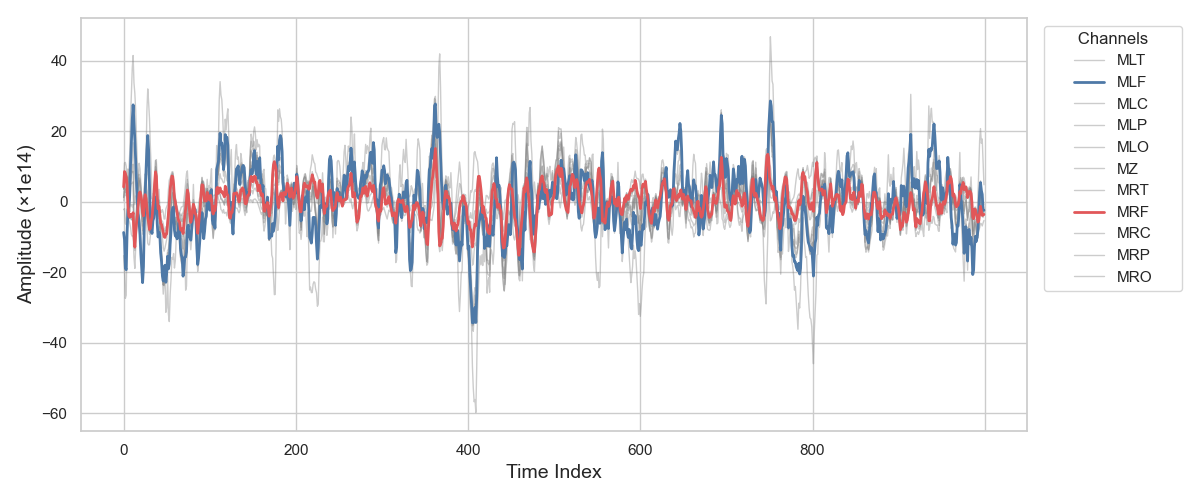

In [5]:
csv_path = os.path.join(all_trials_address[2], 'data_block005.csv')
utils.plot_epoch_activity(csv_path=csv_path, highlight_channels=['MRF', 'MLF'],
    highlight_colors={'MRF': '#e15759', 'MLF': '#4e79a7'})

## Deep Learning

### Train model

Loading Data:   0%|          | 0/50 [00:00<?, ?it/s]

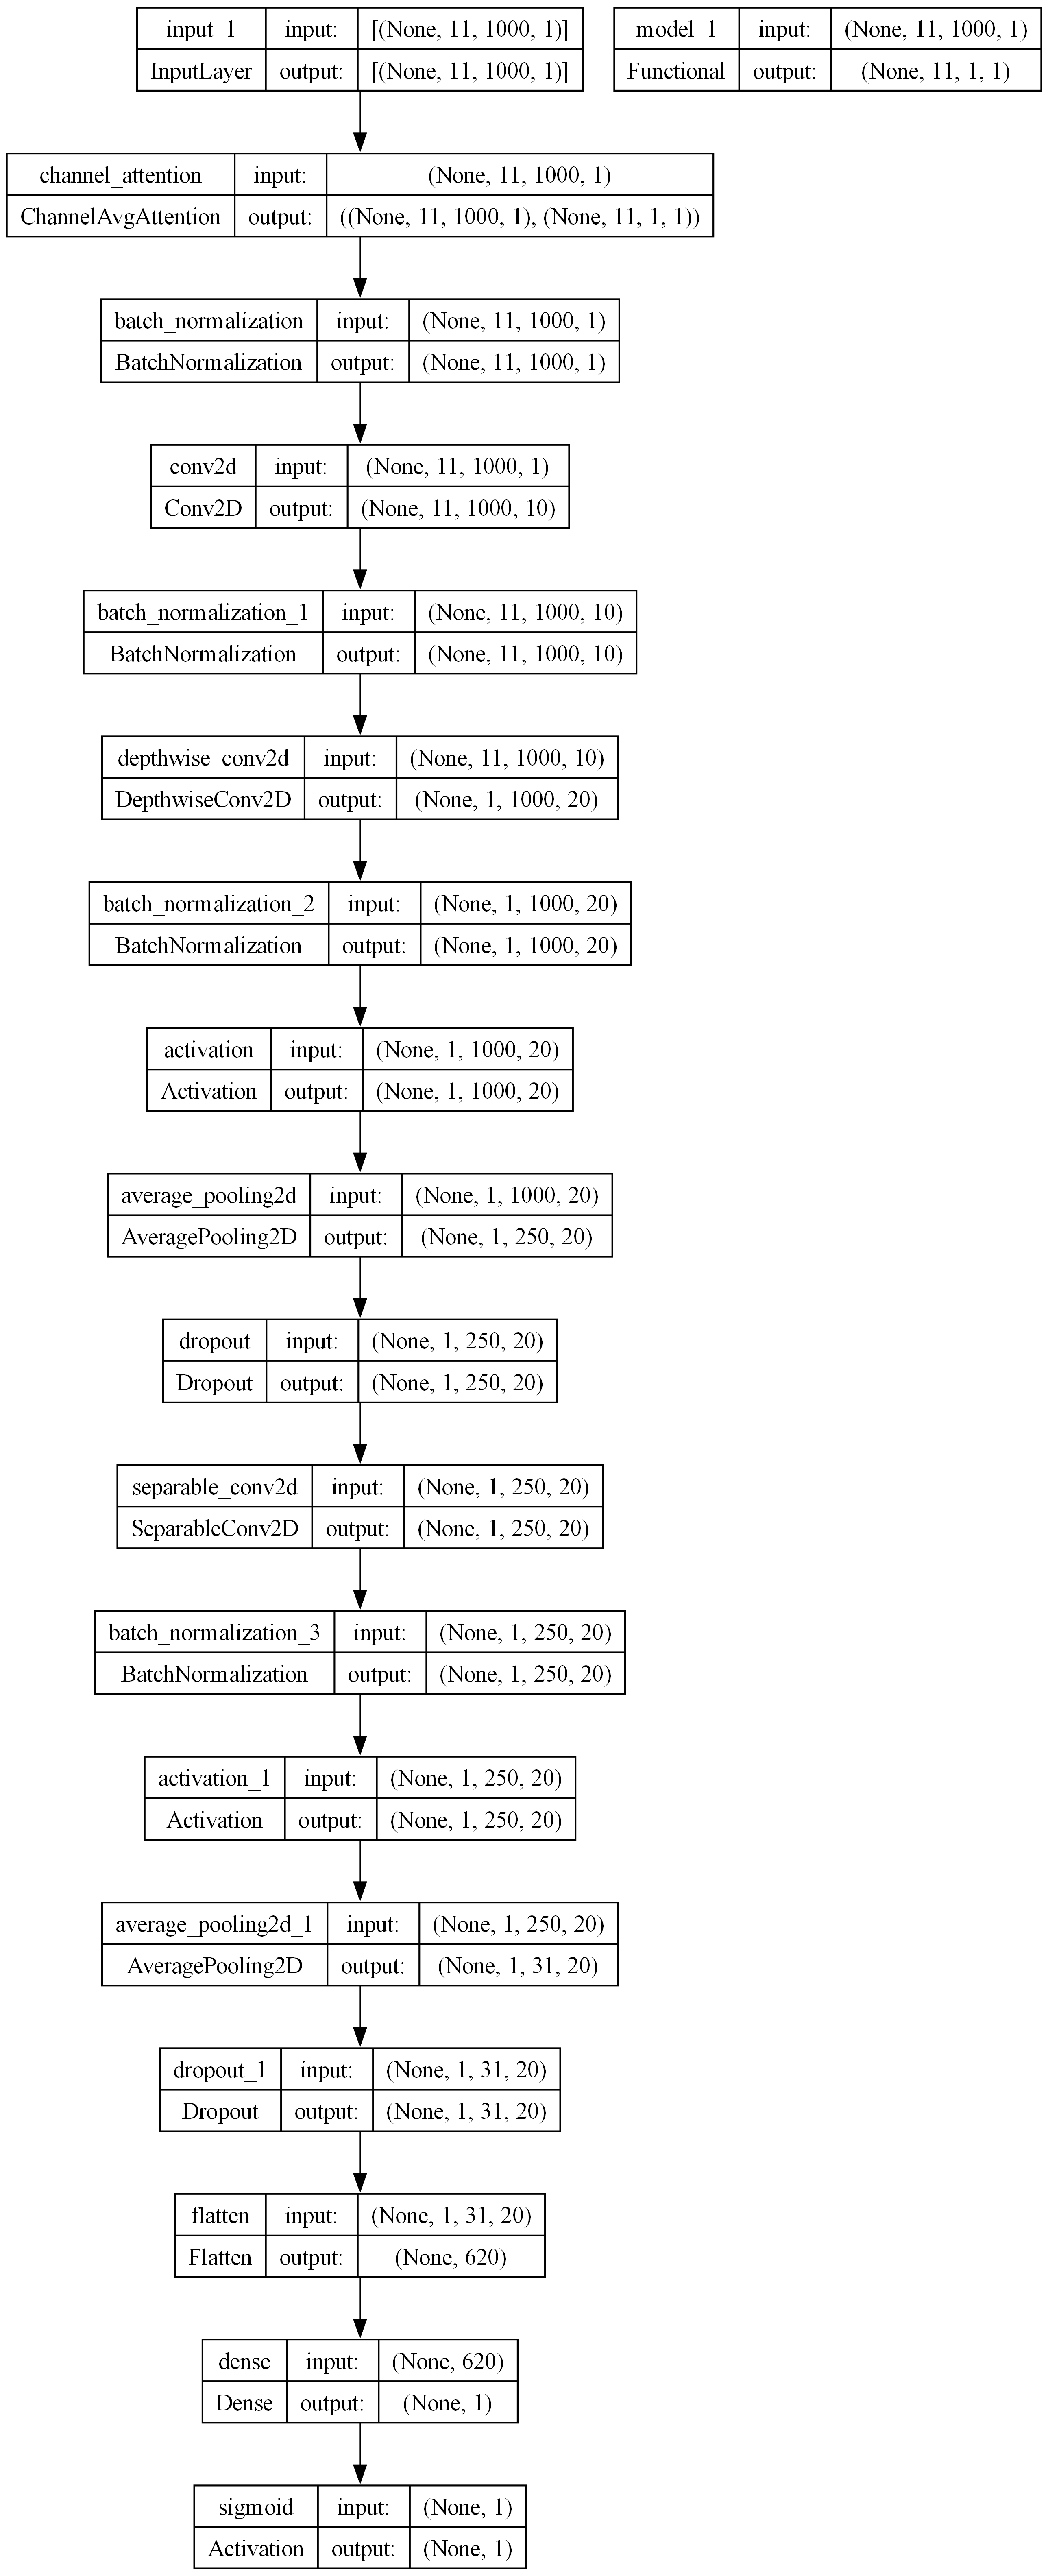

Iteration,Train Acc,Val Acc,Test Acc
0,98.074,84.524,66.667


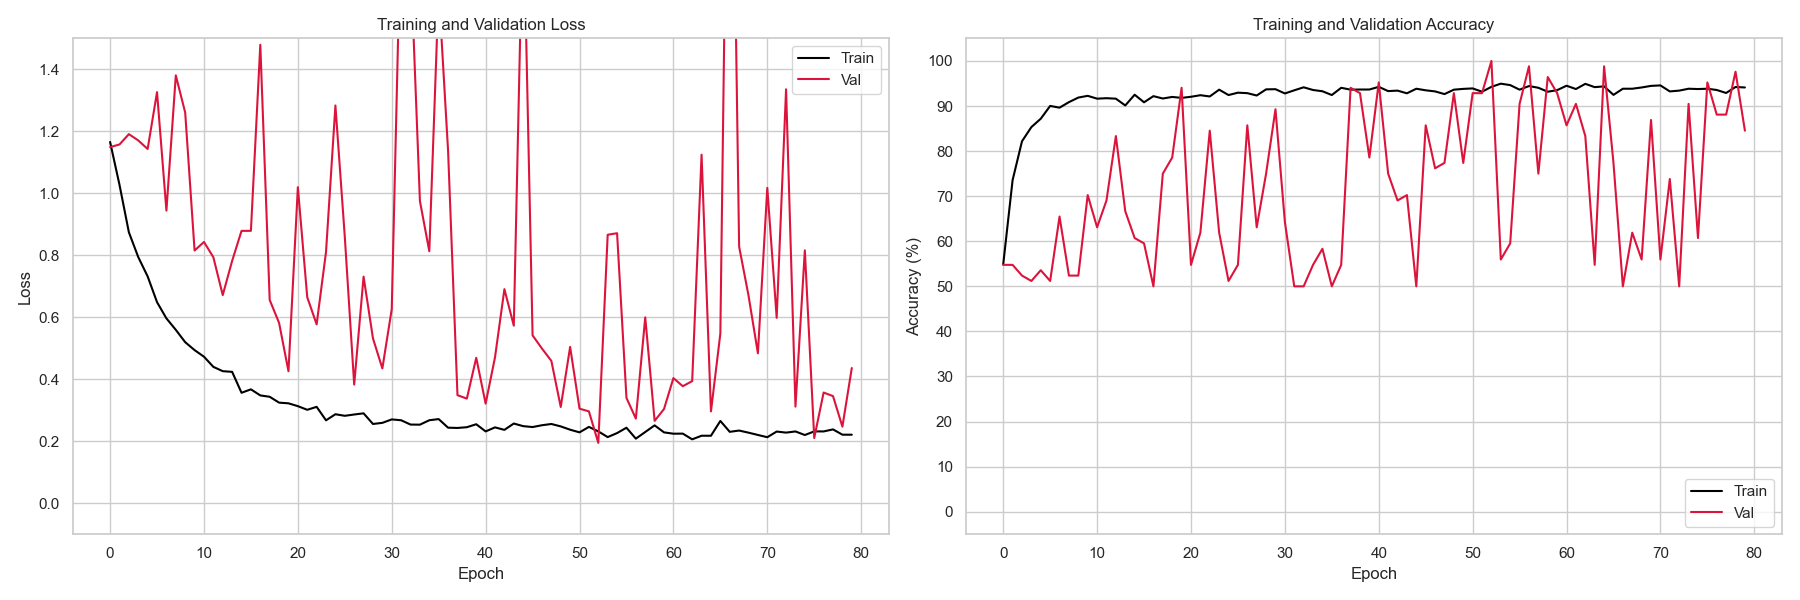

Iteration,Train Acc,Val Acc,Test Acc
1,78.957,50.000,100.000


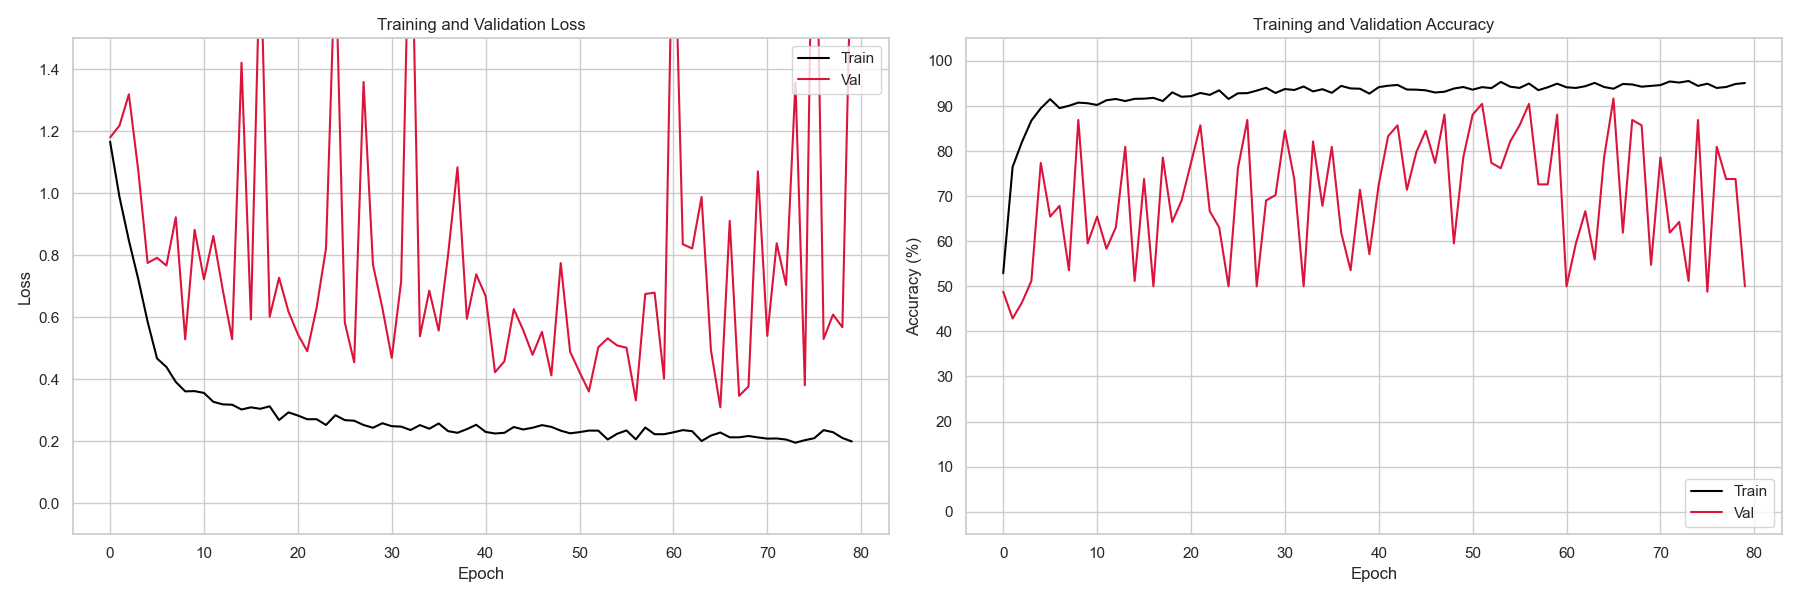

Iteration,Train Acc,Val Acc,Test Acc
2,92.927,89.286,63.333


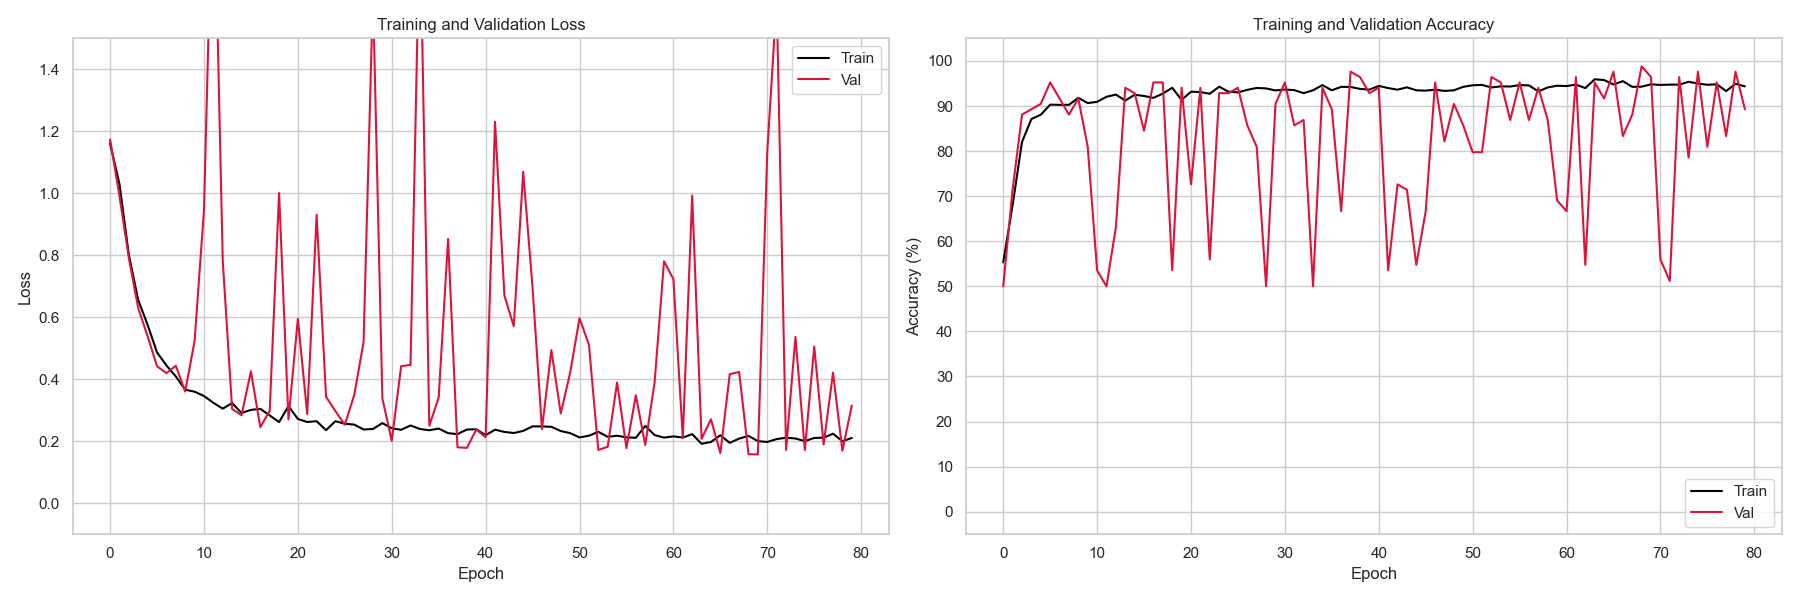

Iteration,Train Acc,Val Acc,Test Acc
3,98.039,95.238,76.667


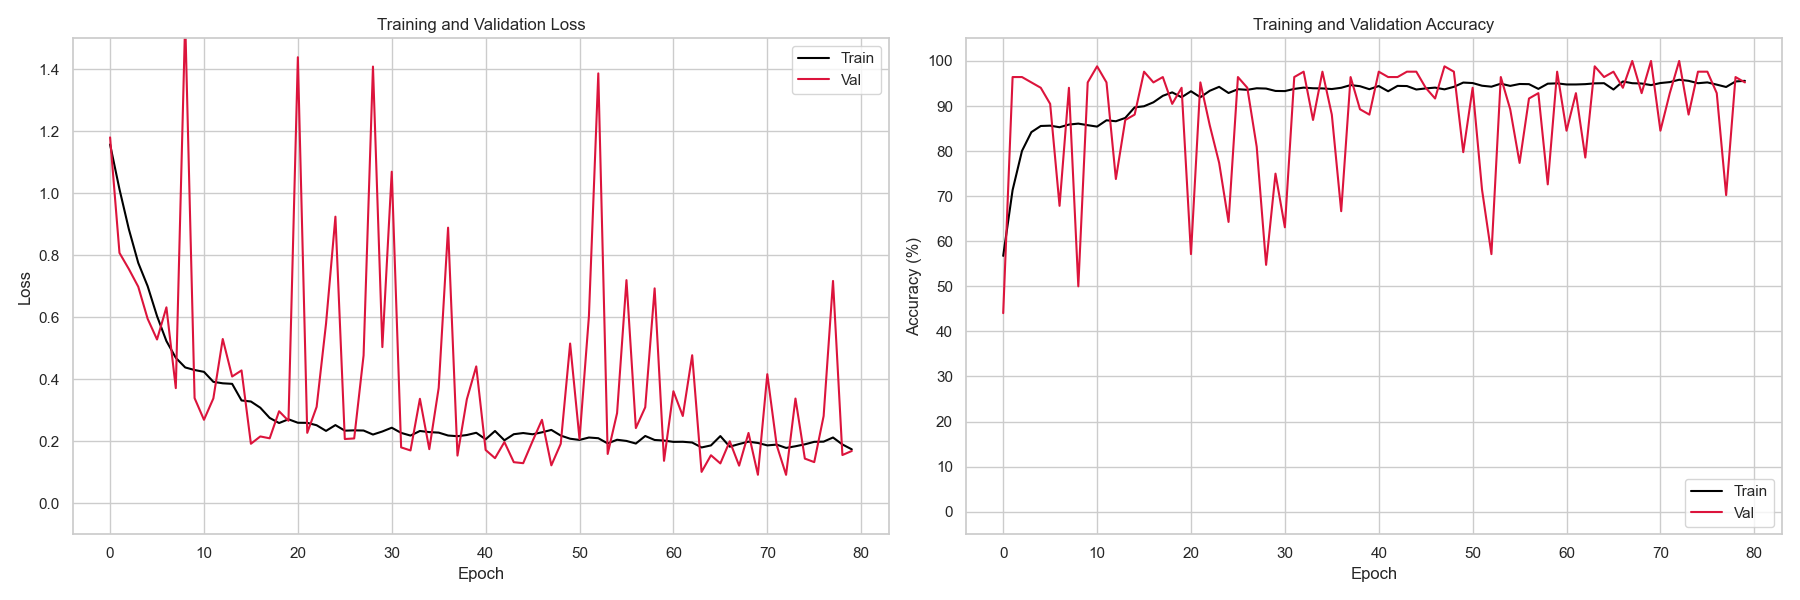

Iteration,Train Acc,Val Acc,Test Acc
4,91.352,90.476,100.000


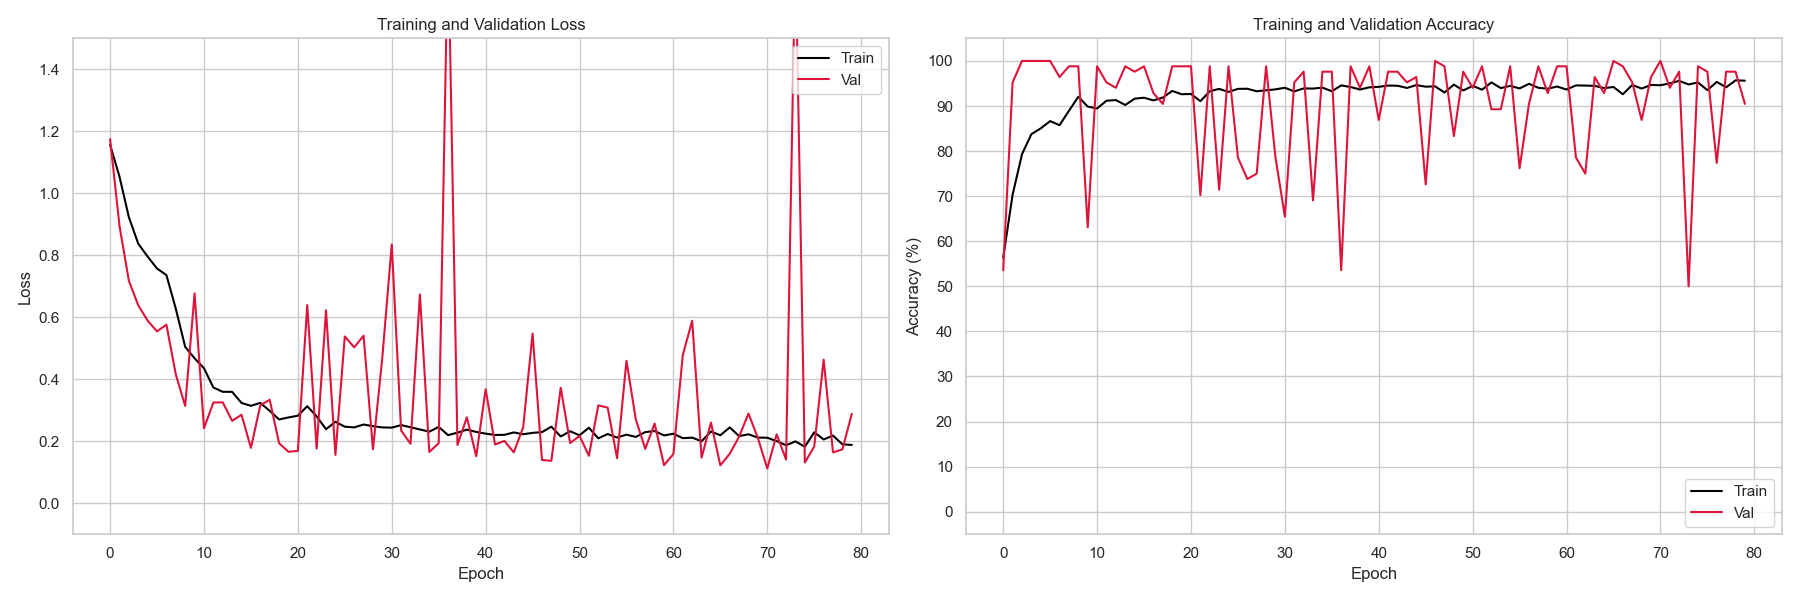

Iteration,Train Acc,Val Acc,Test Acc
5,93.417,92.857,98.333


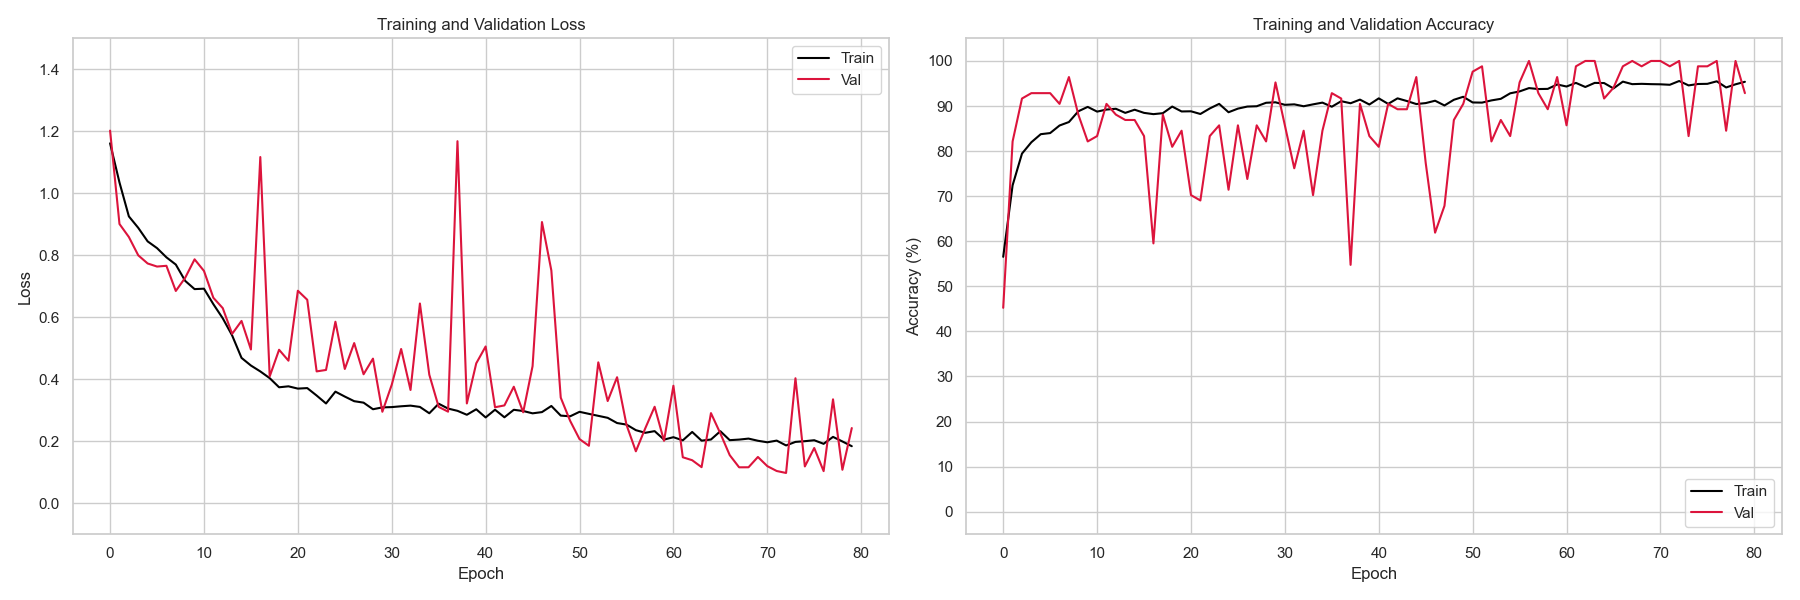

Iteration,Train Acc,Val Acc,Test Acc
6,98.669,100.000,100.000


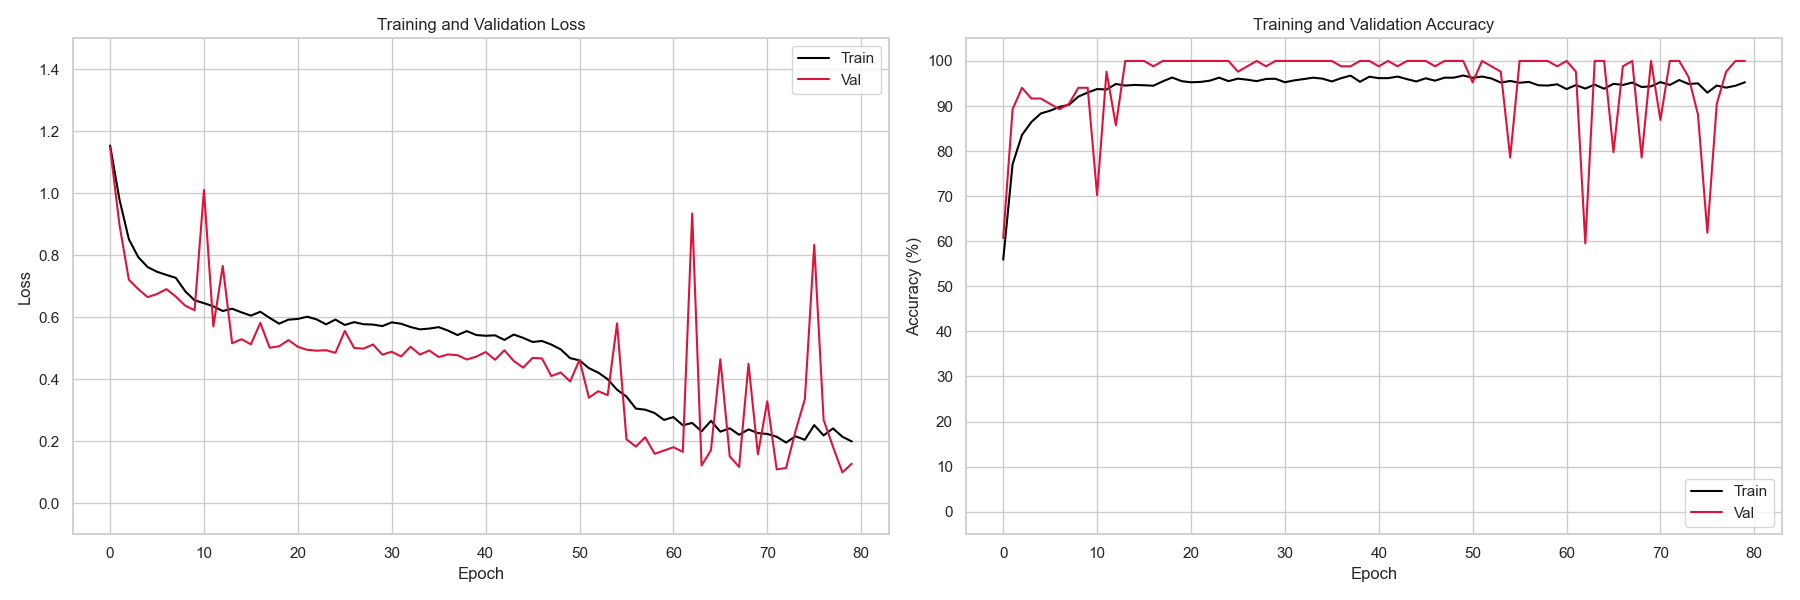

Iteration,Train Acc,Val Acc,Test Acc
7,78.151,50.000,65.000


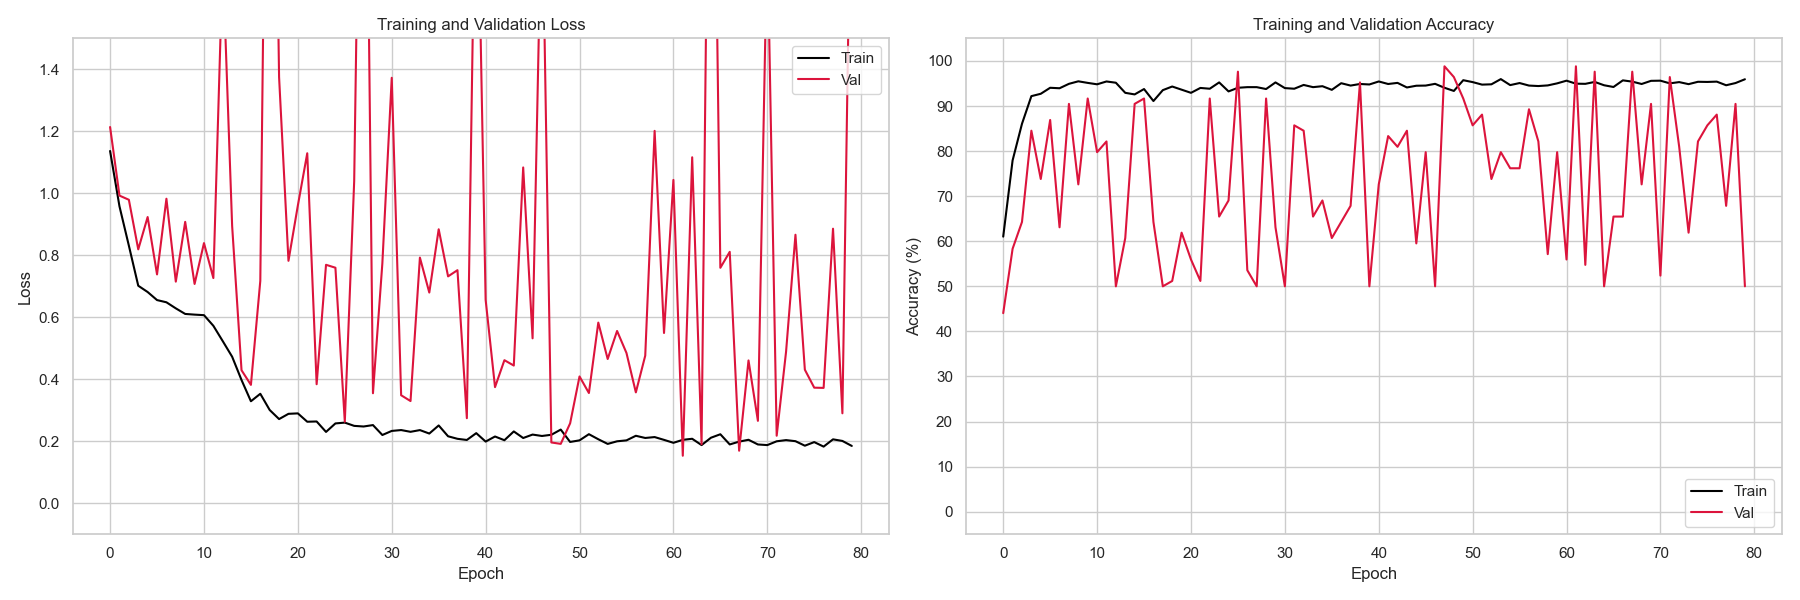

Iteration,Train Acc,Val Acc,Test Acc
8,98.179,92.857,38.333


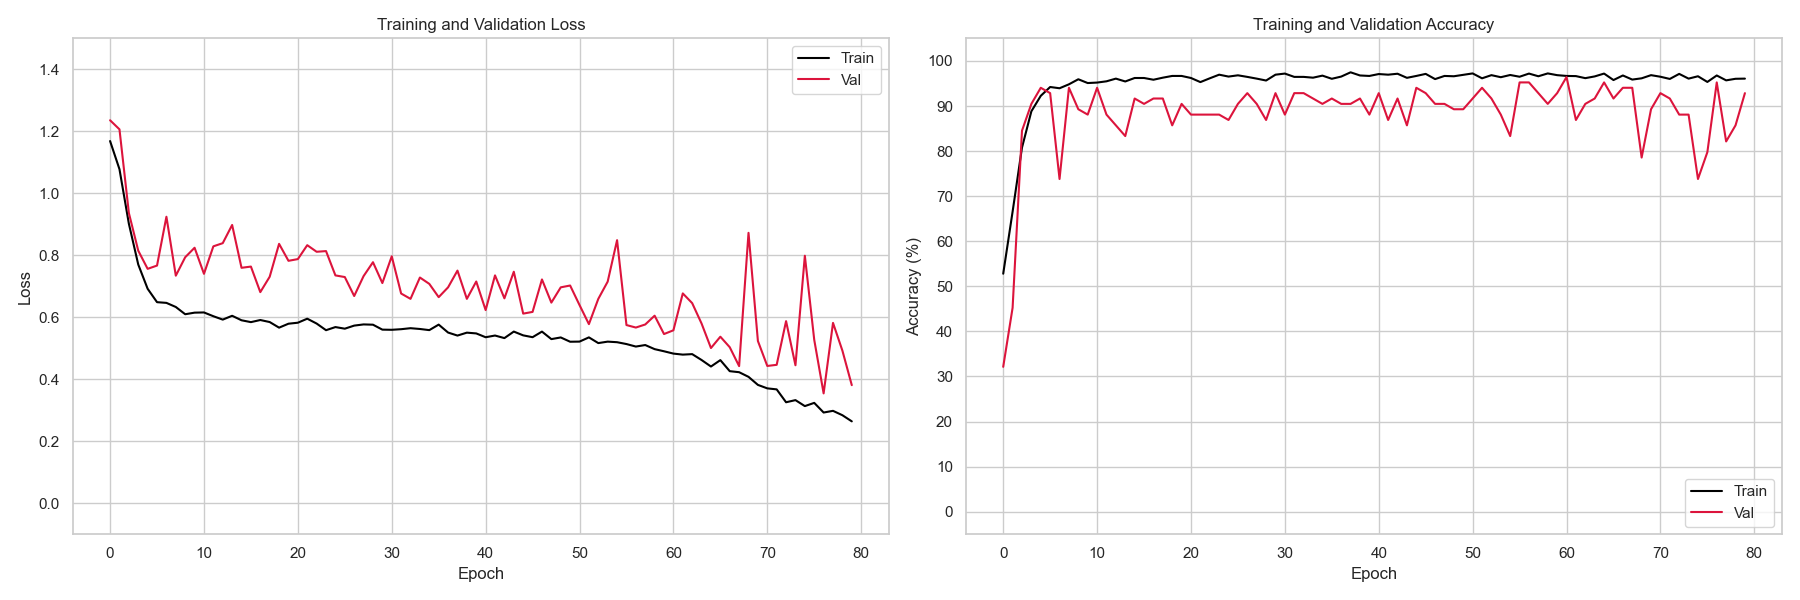

Iteration,Train Acc,Val Acc,Test Acc
9,98.669,95.238,80.000


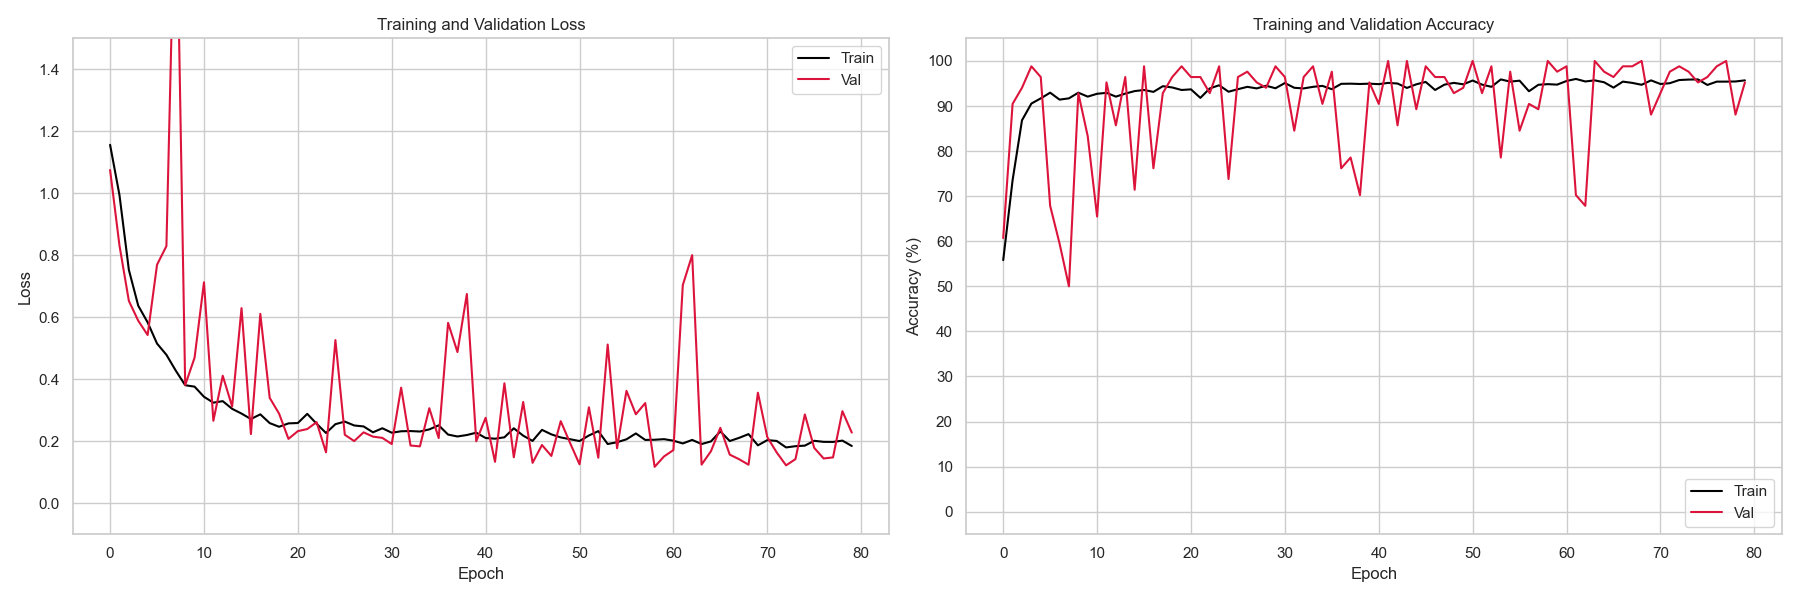

Iteration,Train Acc,Val Acc,Test Acc
10,97.969,85.714,96.667


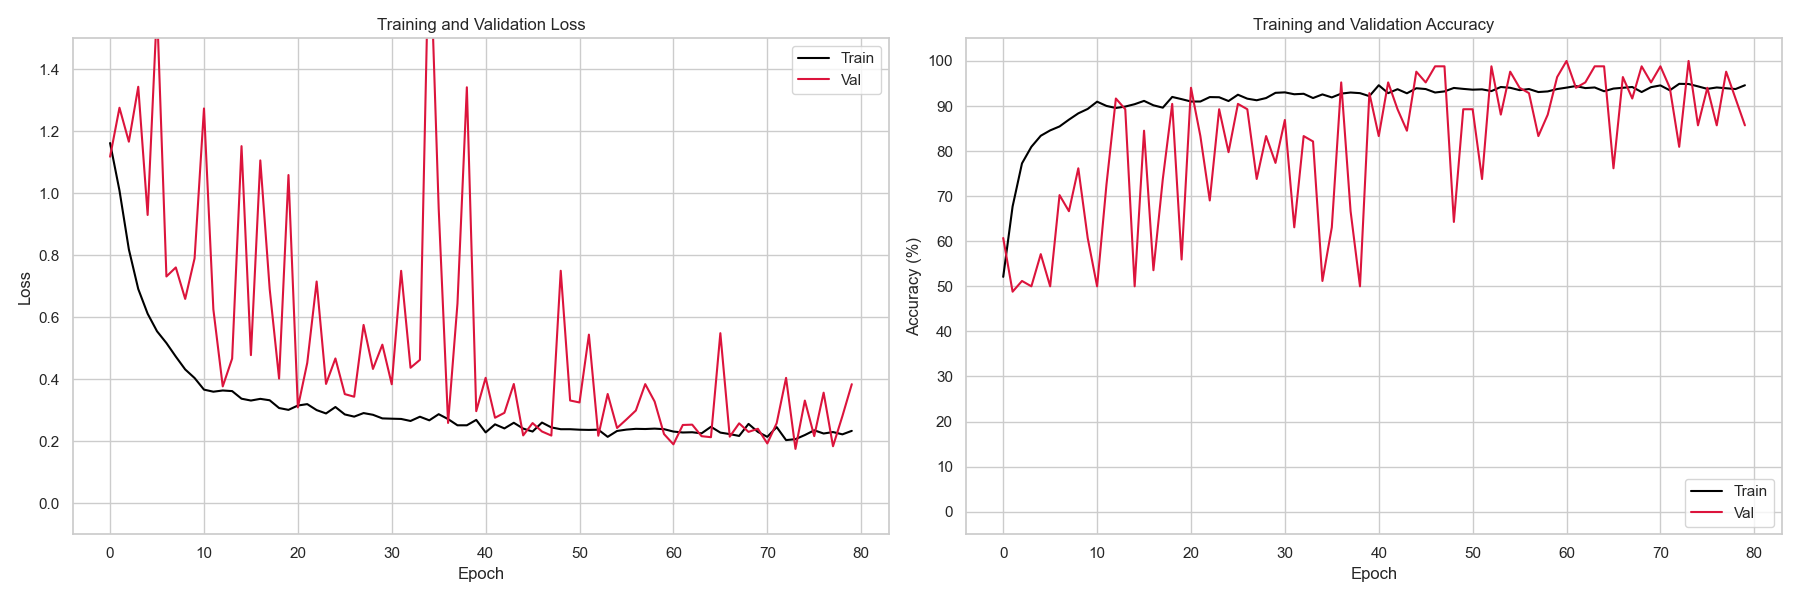

Iteration,Train Acc,Val Acc,Test Acc
11,98.144,92.857,96.667


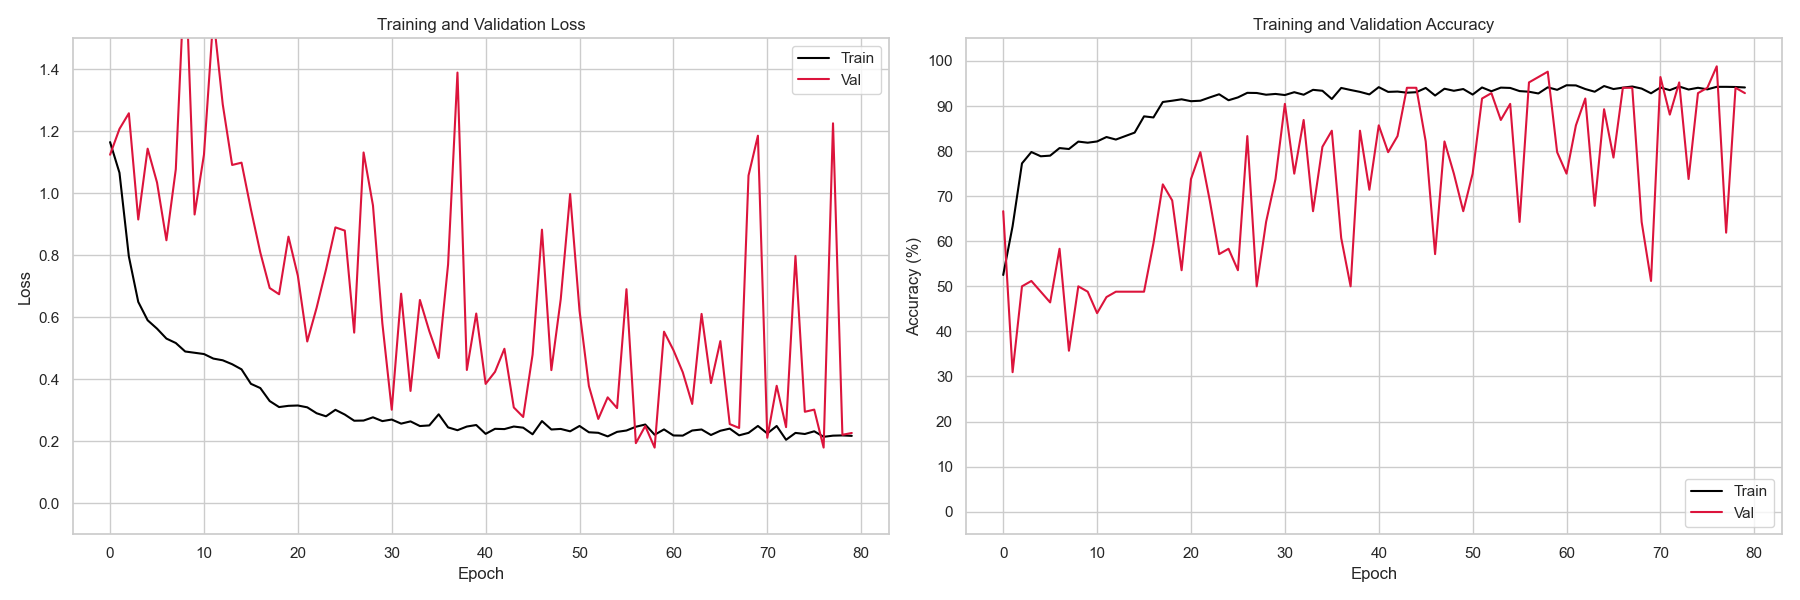

Iteration,Train Acc,Val Acc,Test Acc
12,98.704,98.810,96.667


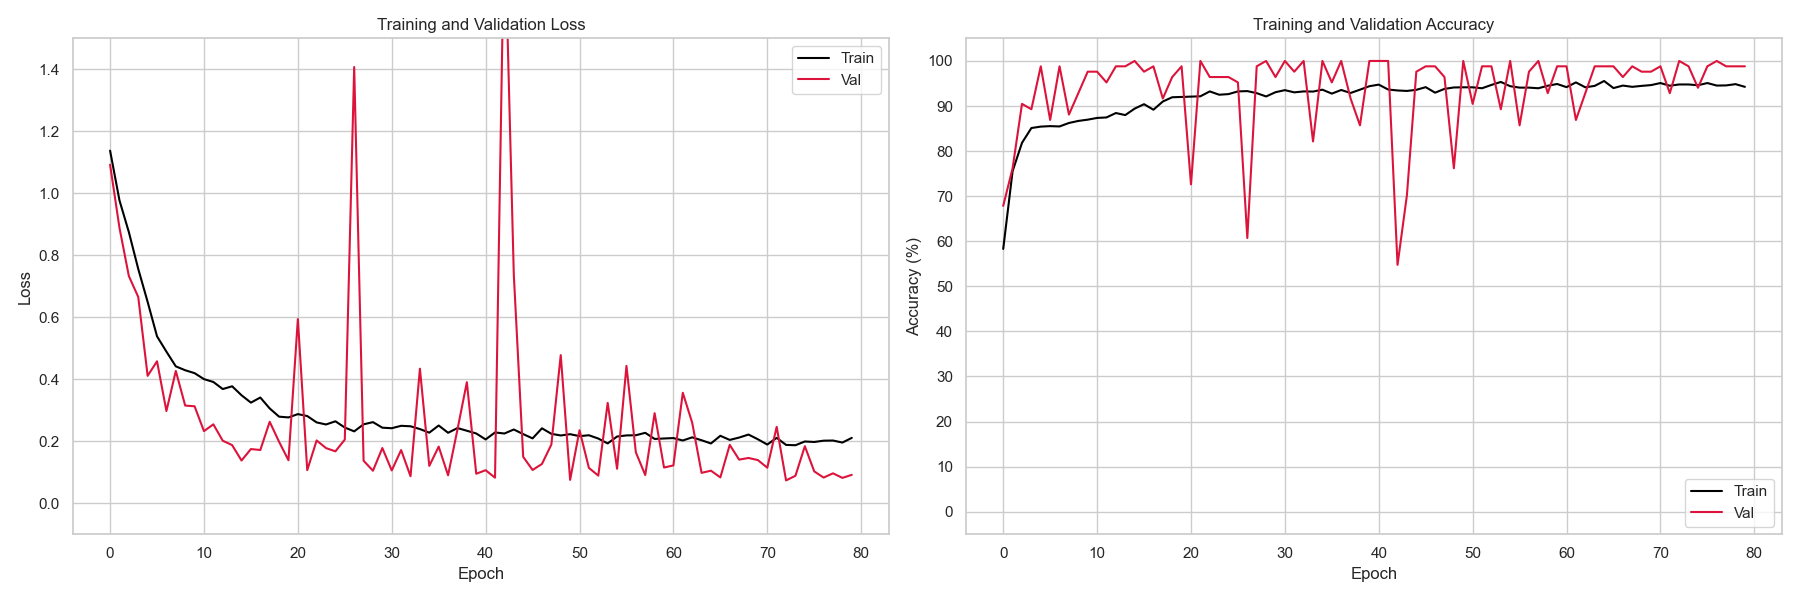

Iteration,Train Acc,Val Acc,Test Acc
13,97.094,100.000,70.000


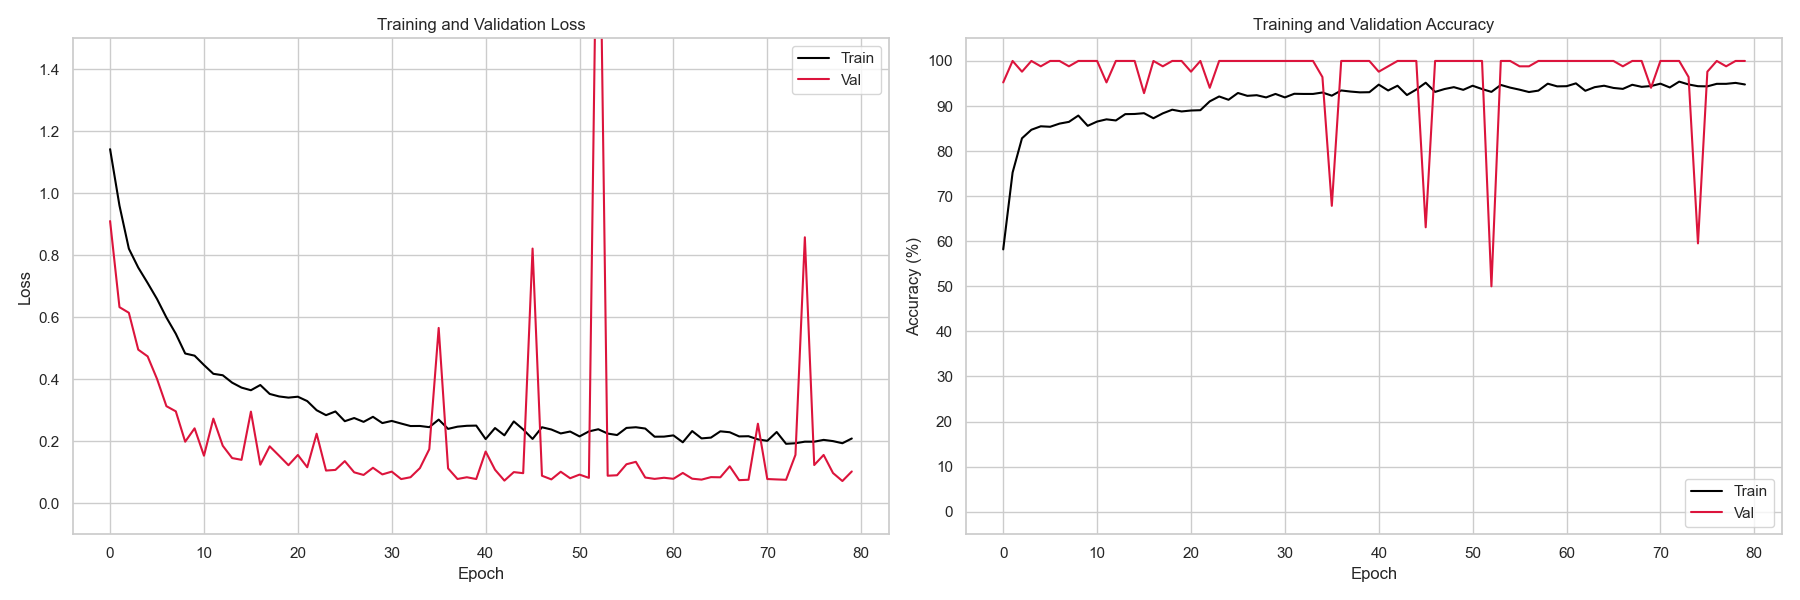

Iteration,Train Acc,Val Acc,Test Acc
14,98.424,98.810,100.000


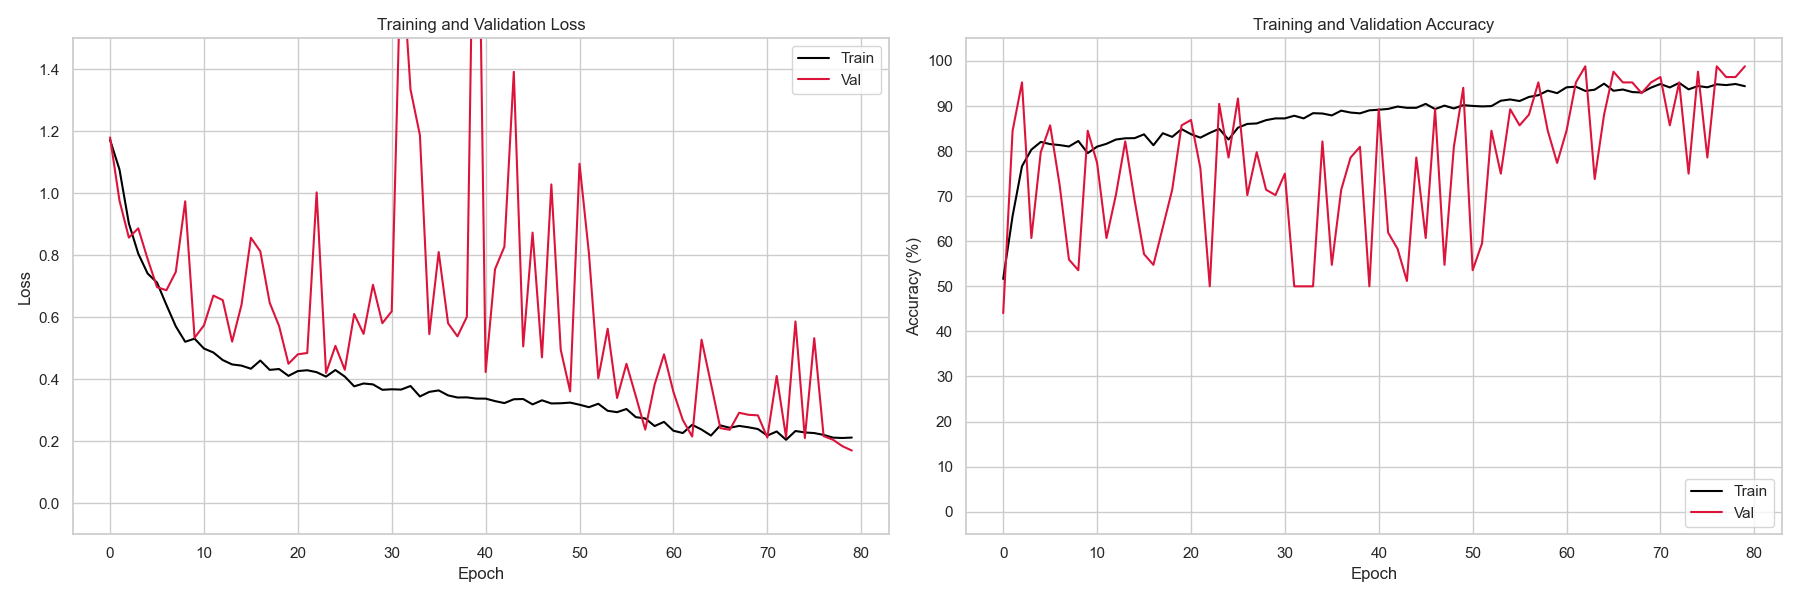

Iteration,Train Acc,Val Acc,Test Acc
15,97.094,83.333,90.000


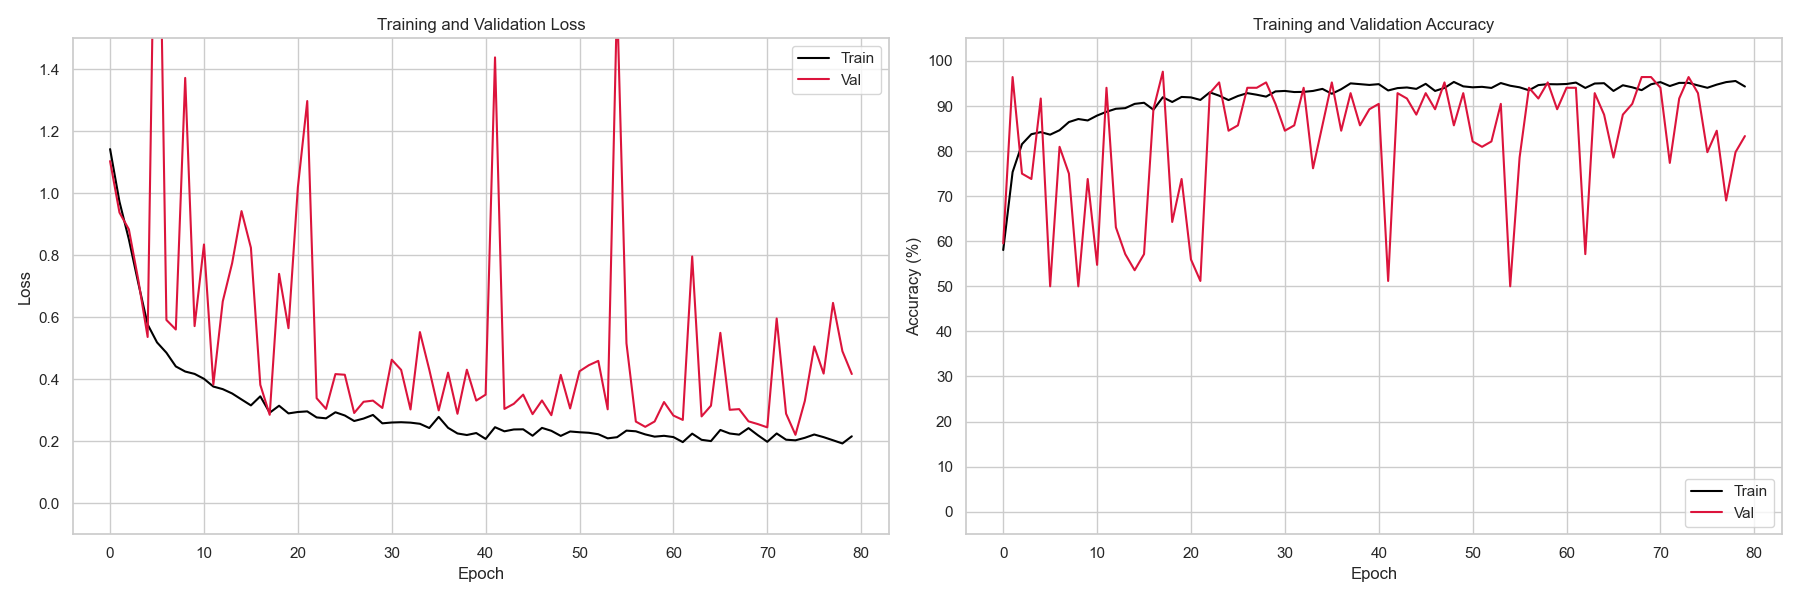

Iteration,Train Acc,Val Acc,Test Acc
16,92.682,98.810,98.333


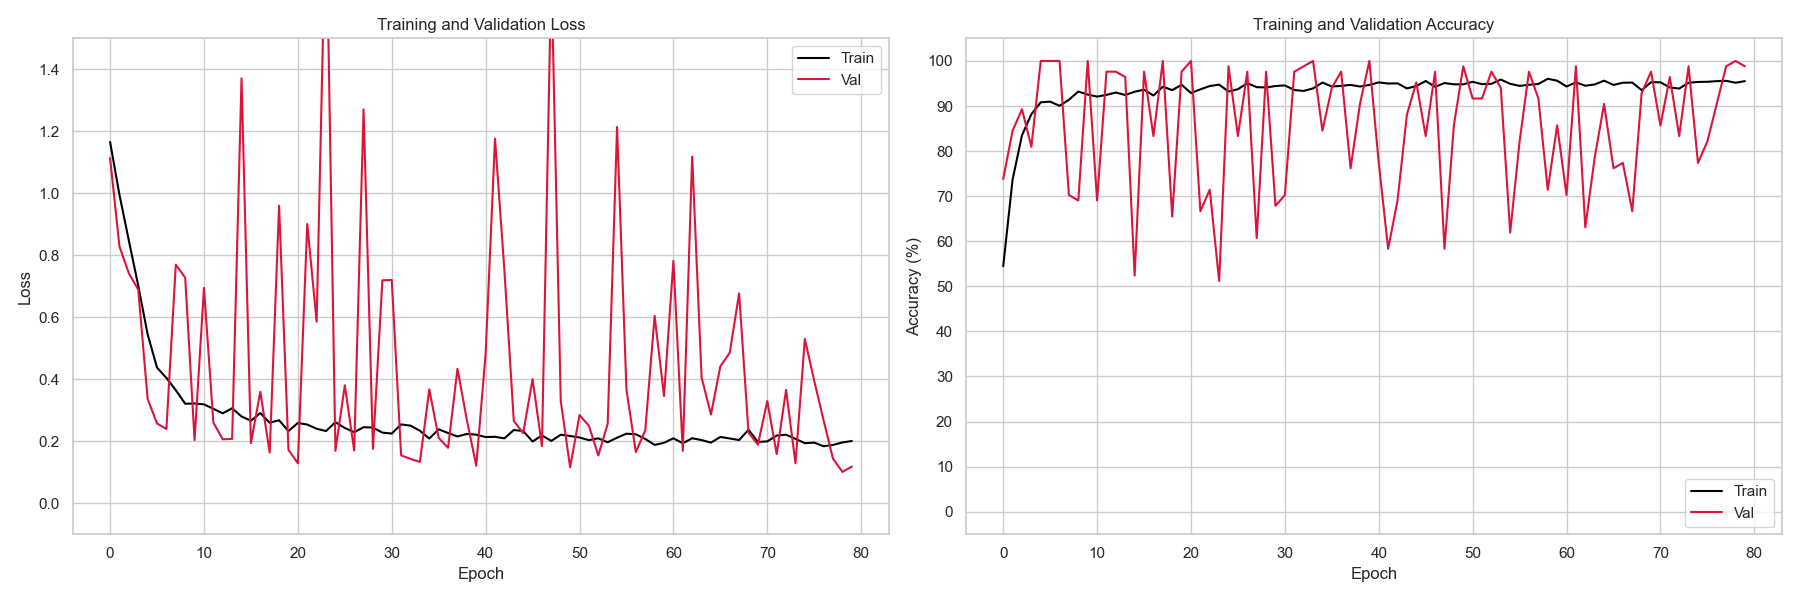

Iteration,Train Acc,Val Acc,Test Acc
17,98.634,100.000,95.000


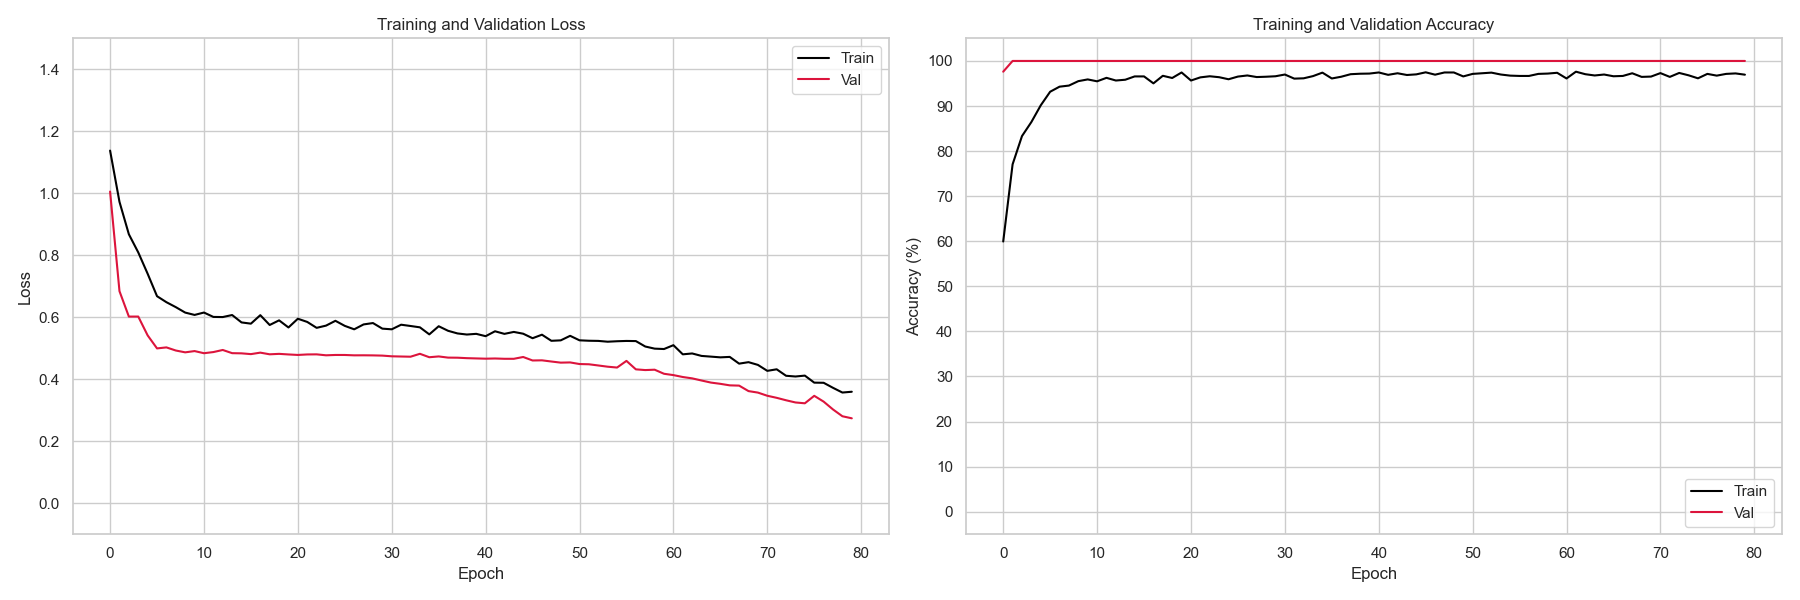

Iteration,Train Acc,Val Acc,Test Acc
18,96.008,100.000,100.000


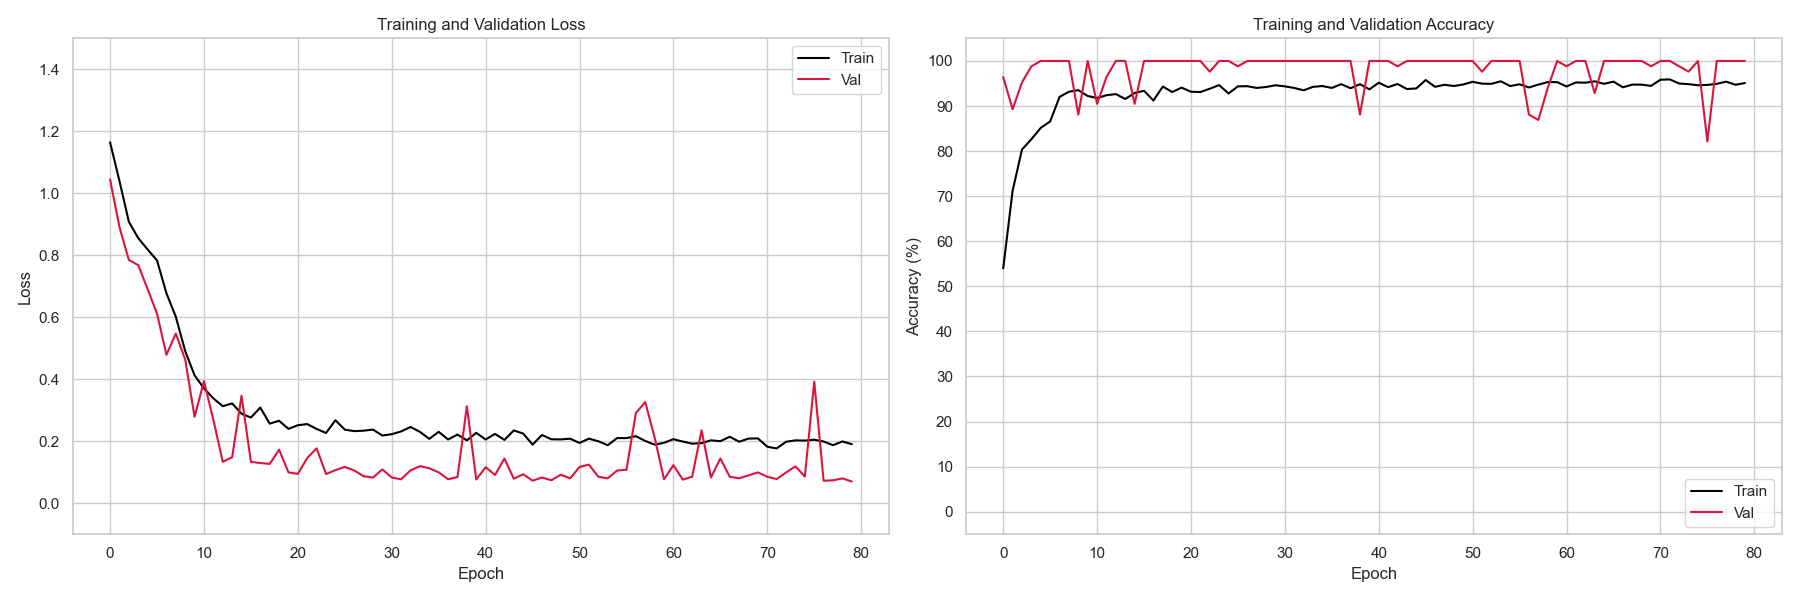

Iteration,Train Acc,Val Acc,Test Acc
19,94.188,88.095,100.000


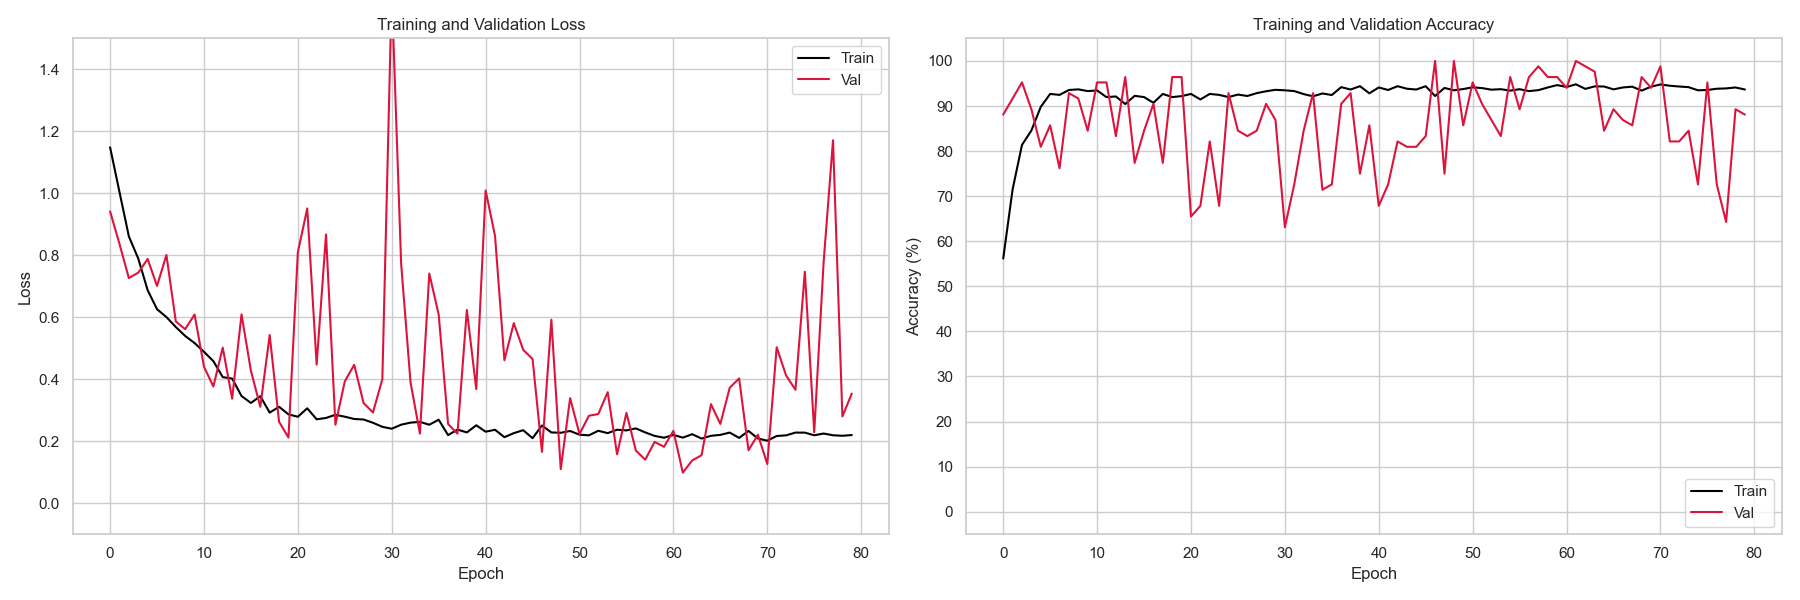

Iteration,Train Acc,Val Acc,Test Acc
20,98.564,98.810,100.000


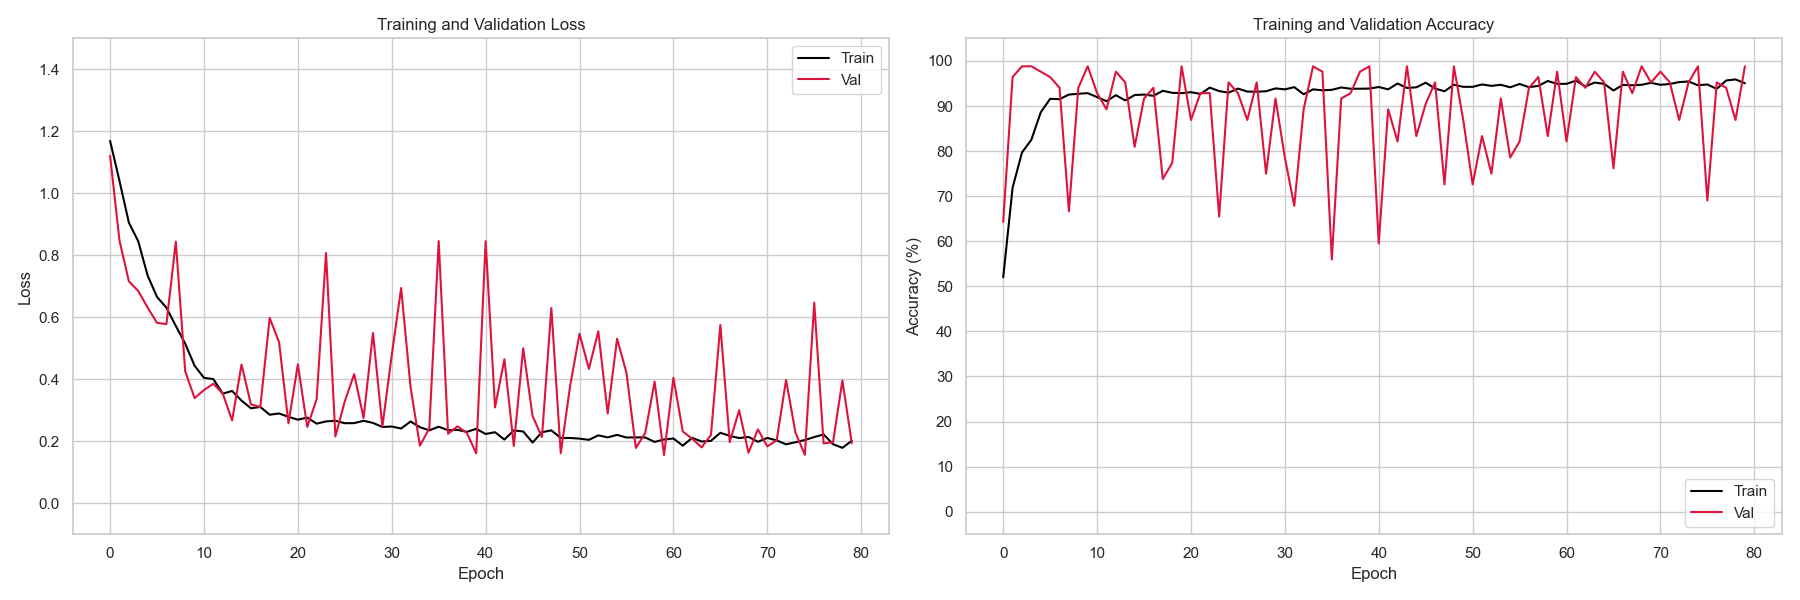

Iteration,Train Acc,Val Acc,Test Acc
21,97.094,95.238,80.000


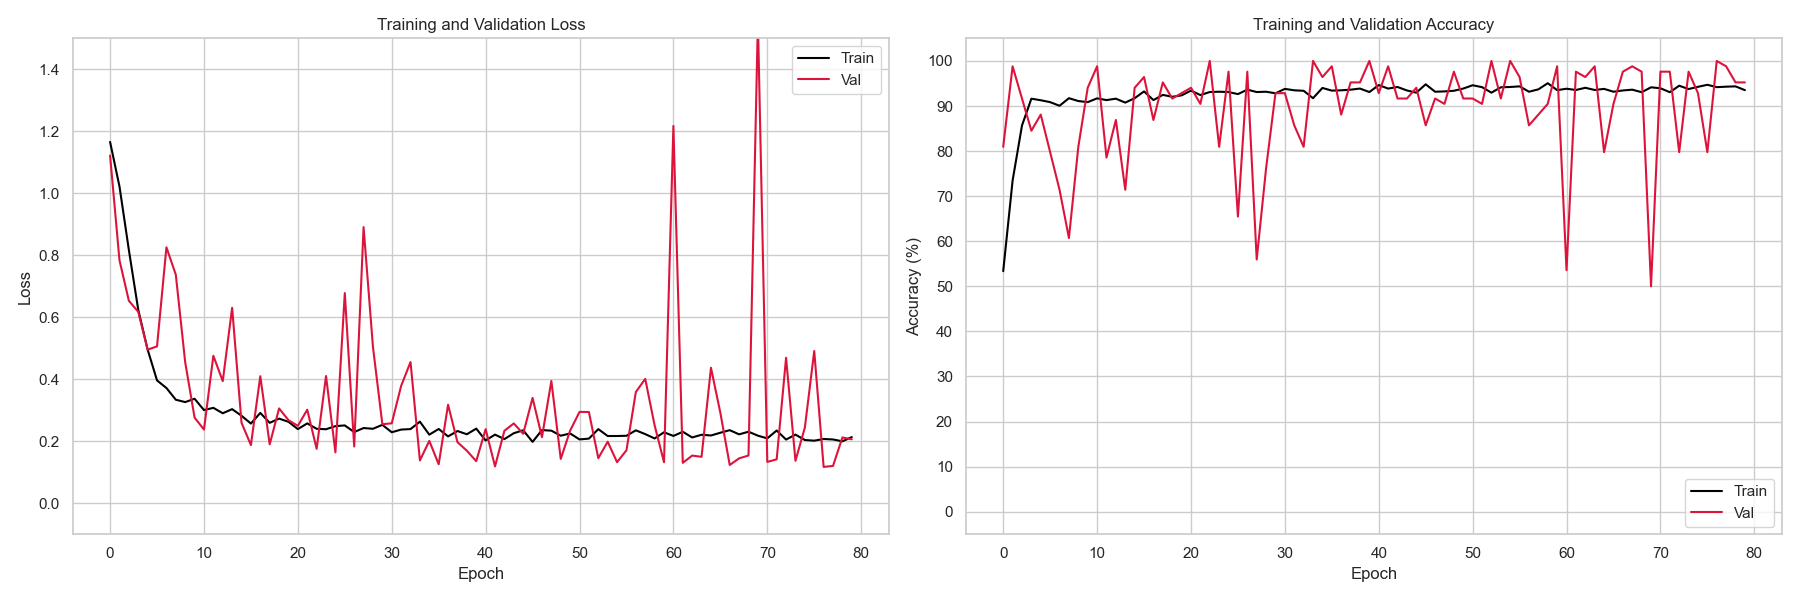

Iteration,Train Acc,Val Acc,Test Acc
22,93.627,100.000,66.667


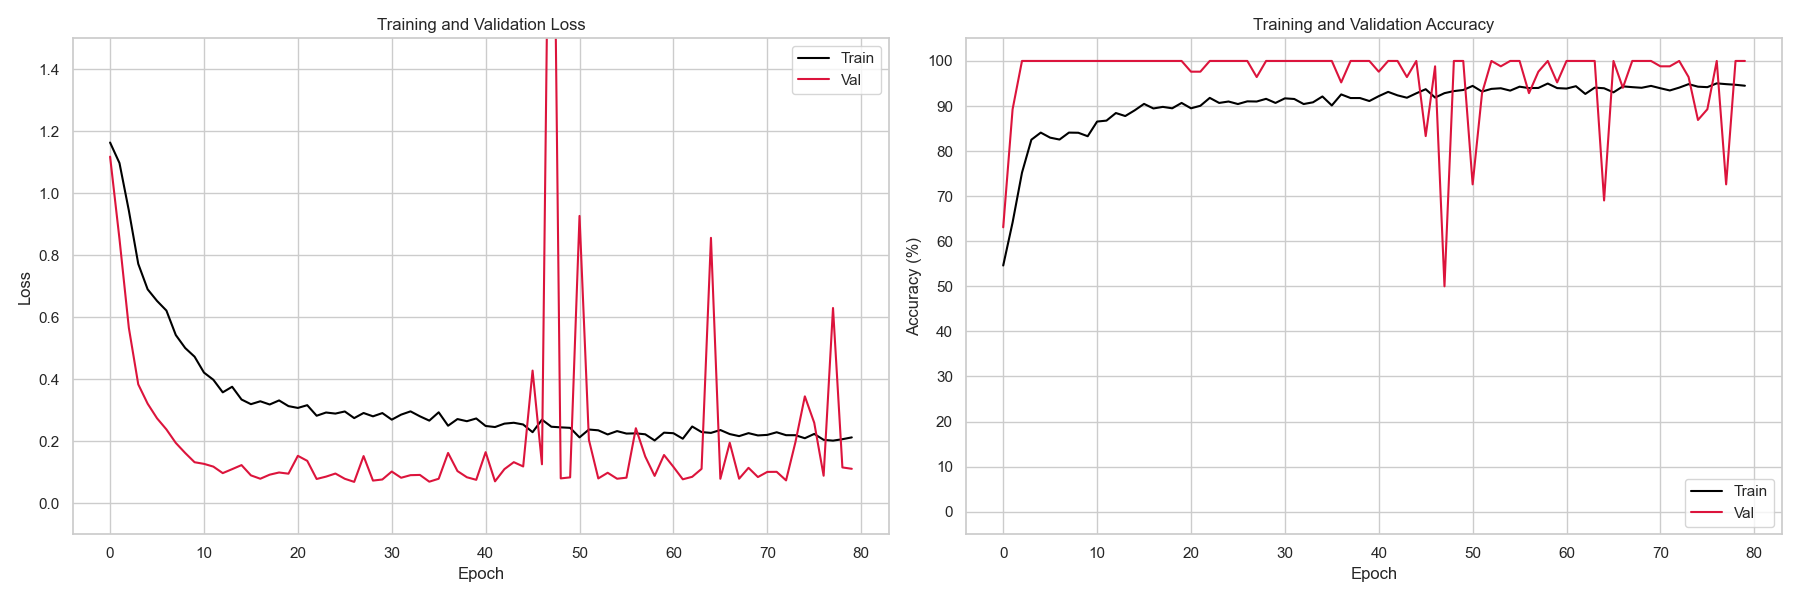

Iteration,Train Acc,Val Acc,Test Acc
23,74.685,100.000,100.000


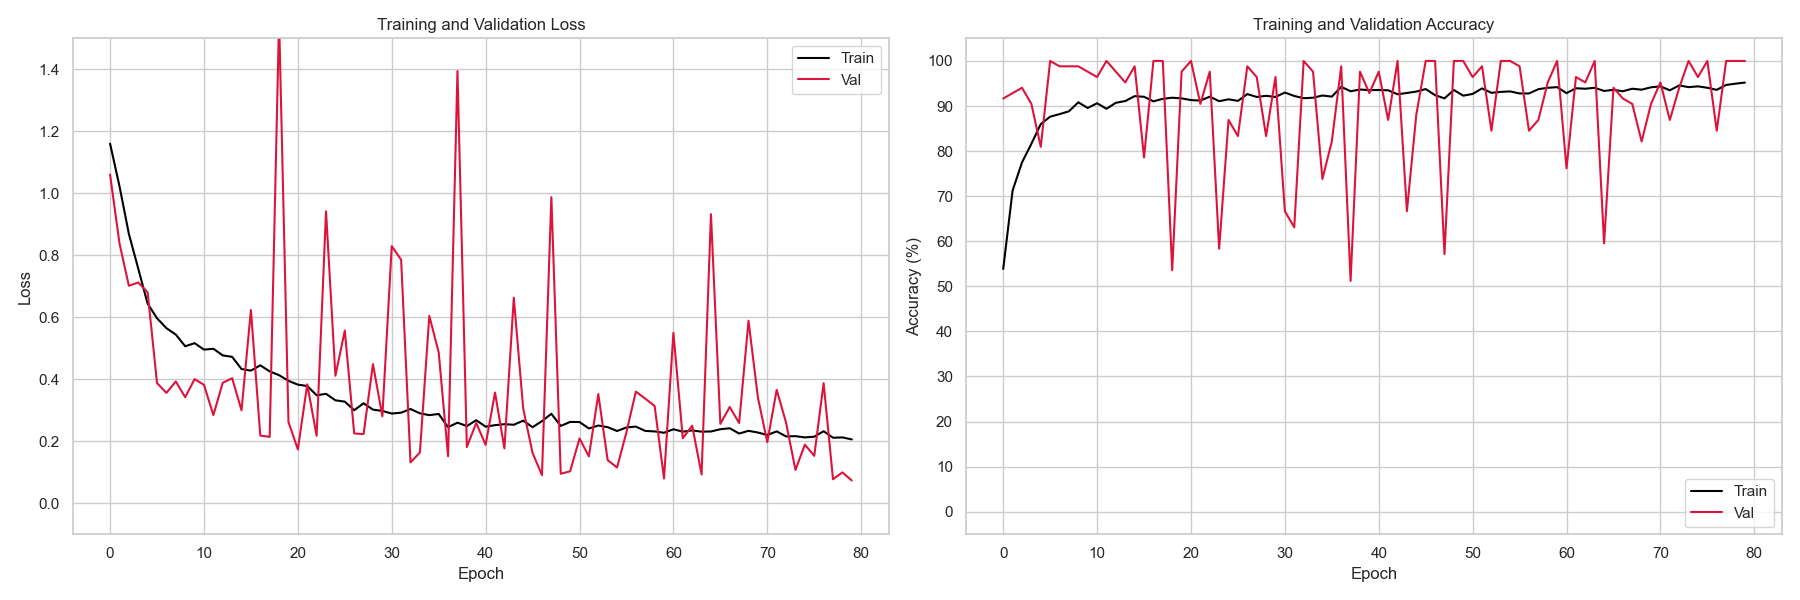

Iteration,Train Acc,Val Acc,Test Acc
24,89.076,82.143,100.000


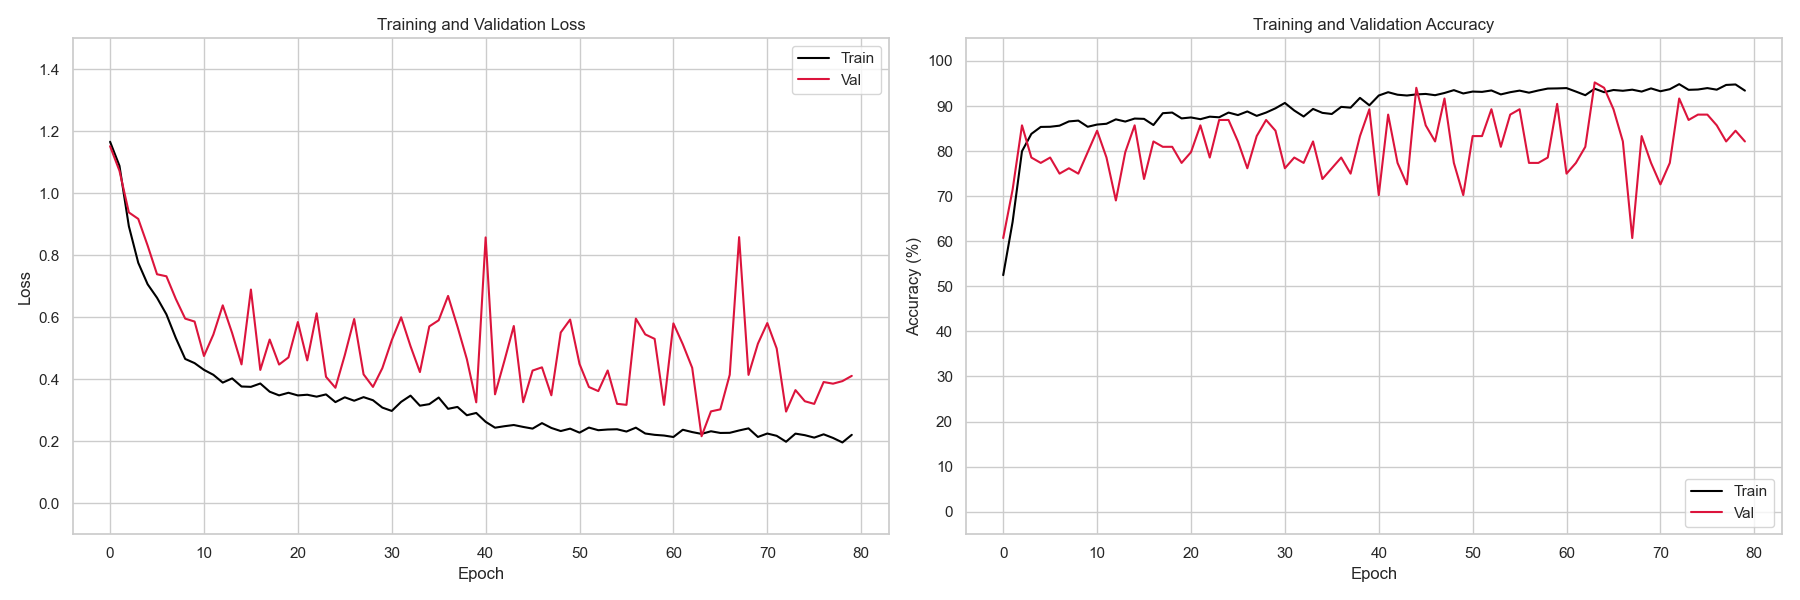

Iteration,Train Acc,Val Acc,Test Acc
25,95.028,82.143,100.000


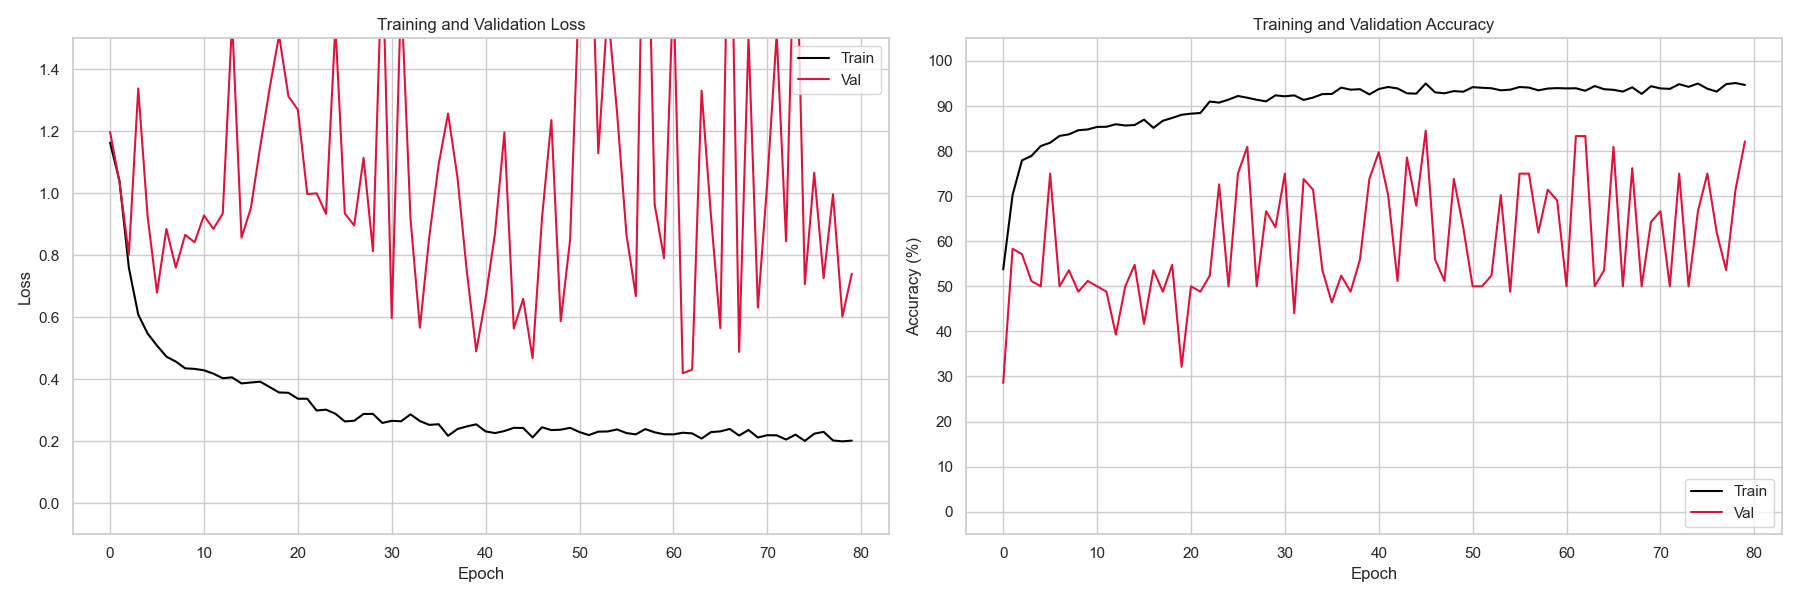

Iteration,Train Acc,Val Acc,Test Acc
26,87.080,80.952,36.667


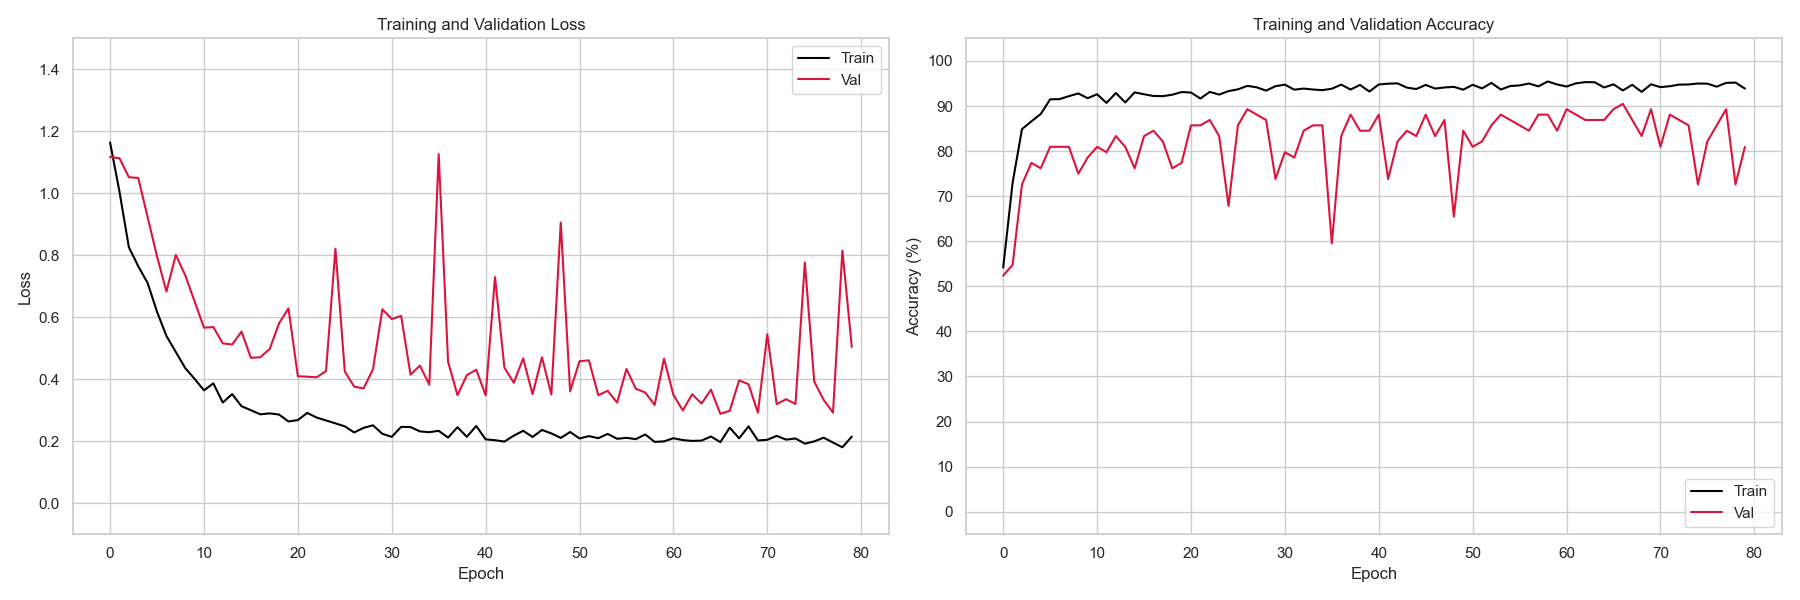

Iteration,Train Acc,Val Acc,Test Acc
27,98.985,91.667,61.667


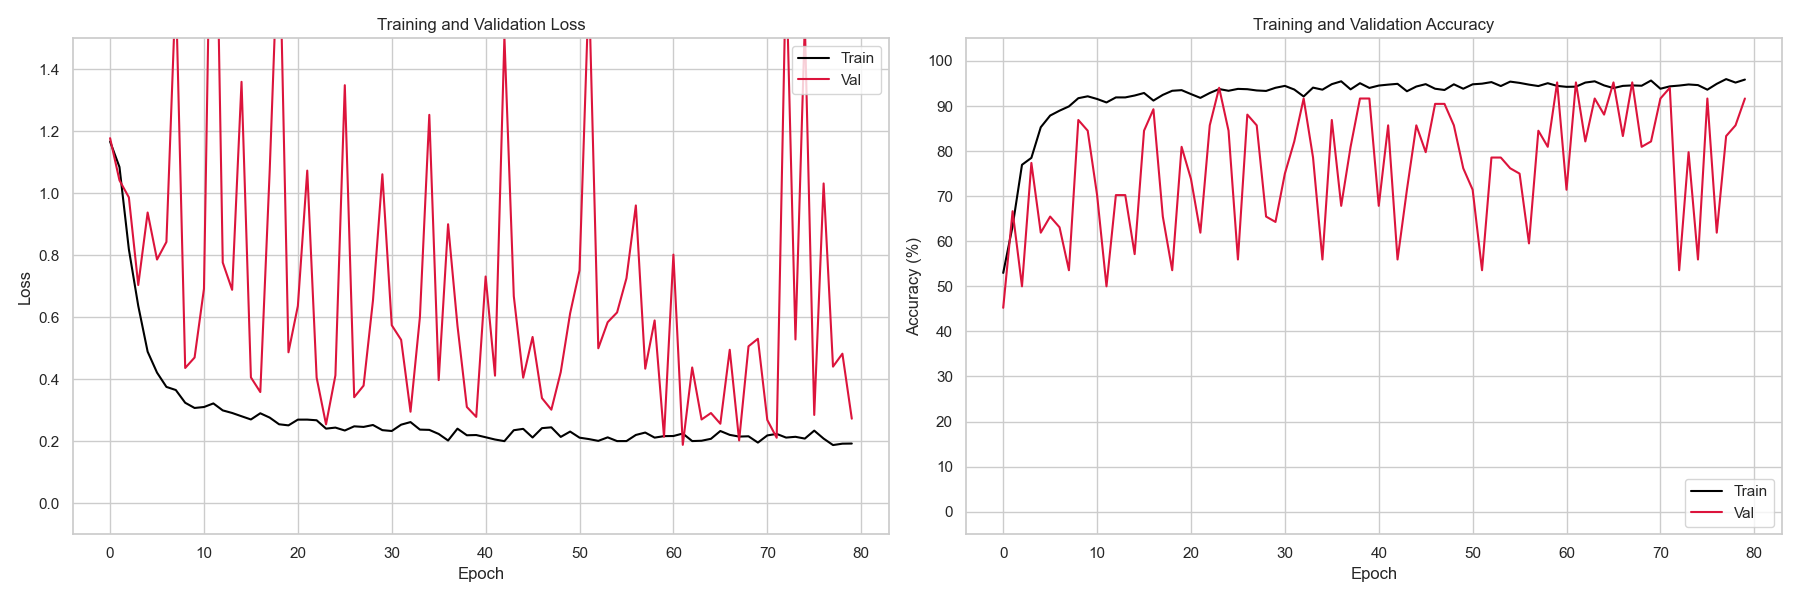

Iteration,Train Acc,Val Acc,Test Acc
28,95.693,89.286,100.000


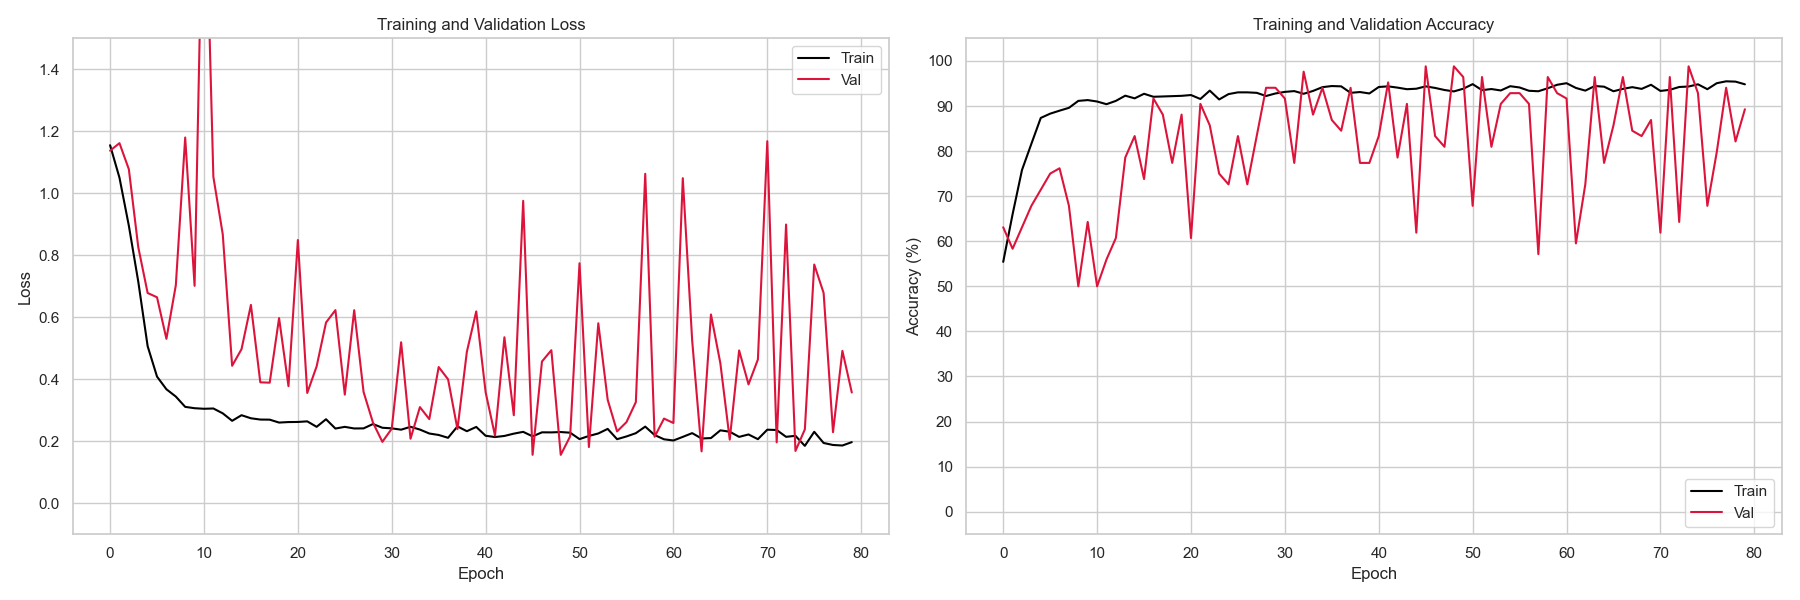

Iteration,Train Acc,Val Acc,Test Acc
29,89.426,85.714,86.667


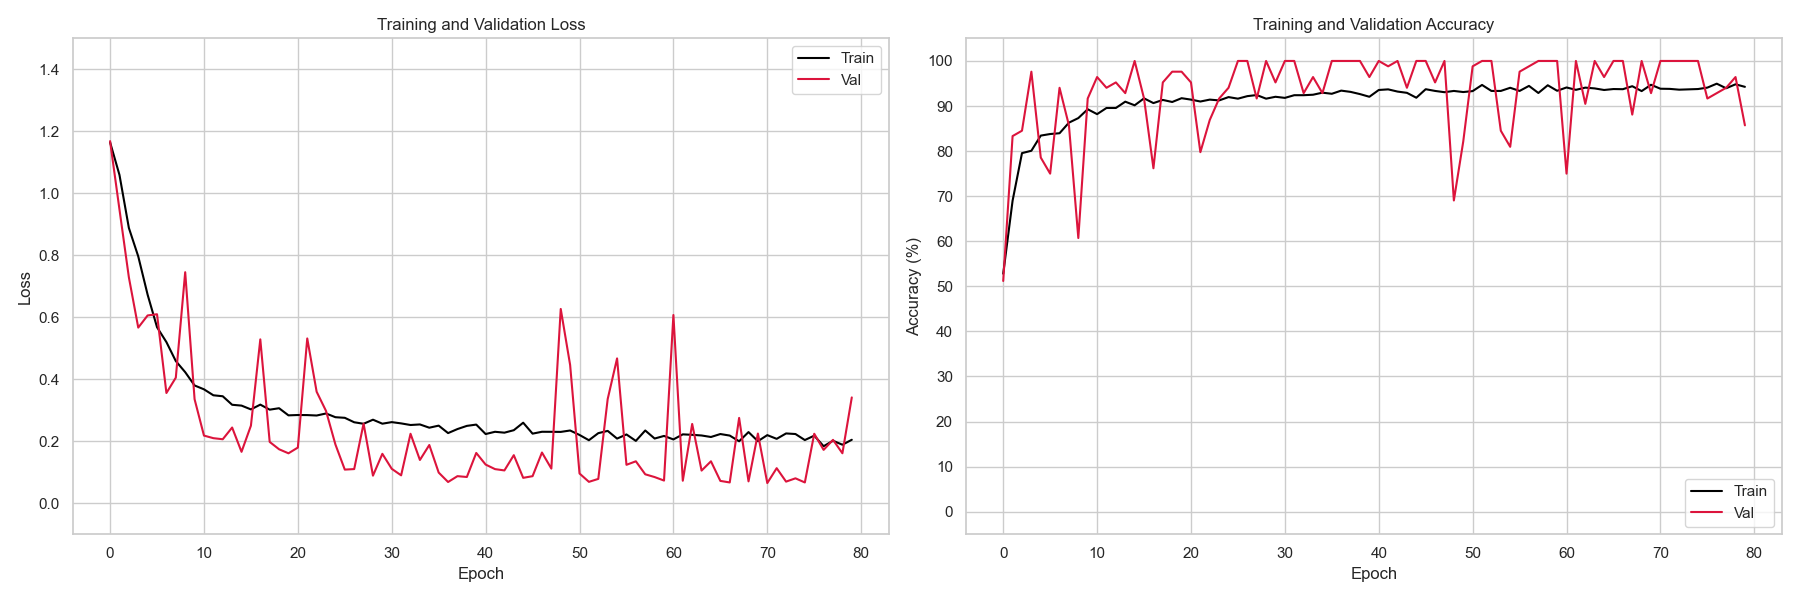

Iteration,Train Acc,Val Acc,Test Acc
30,96.394,75.000,88.333


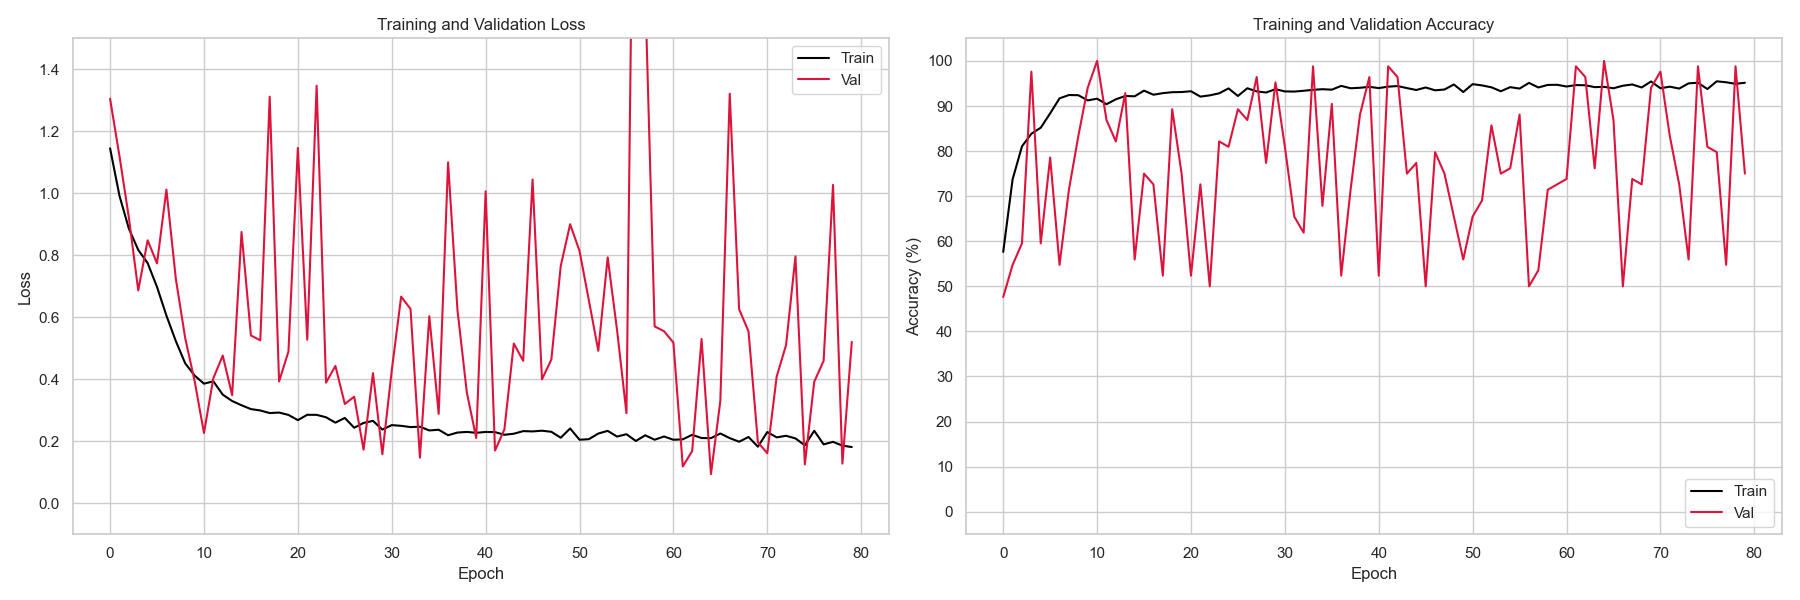

Iteration,Train Acc,Val Acc,Test Acc
31,98.599,85.714,100.000


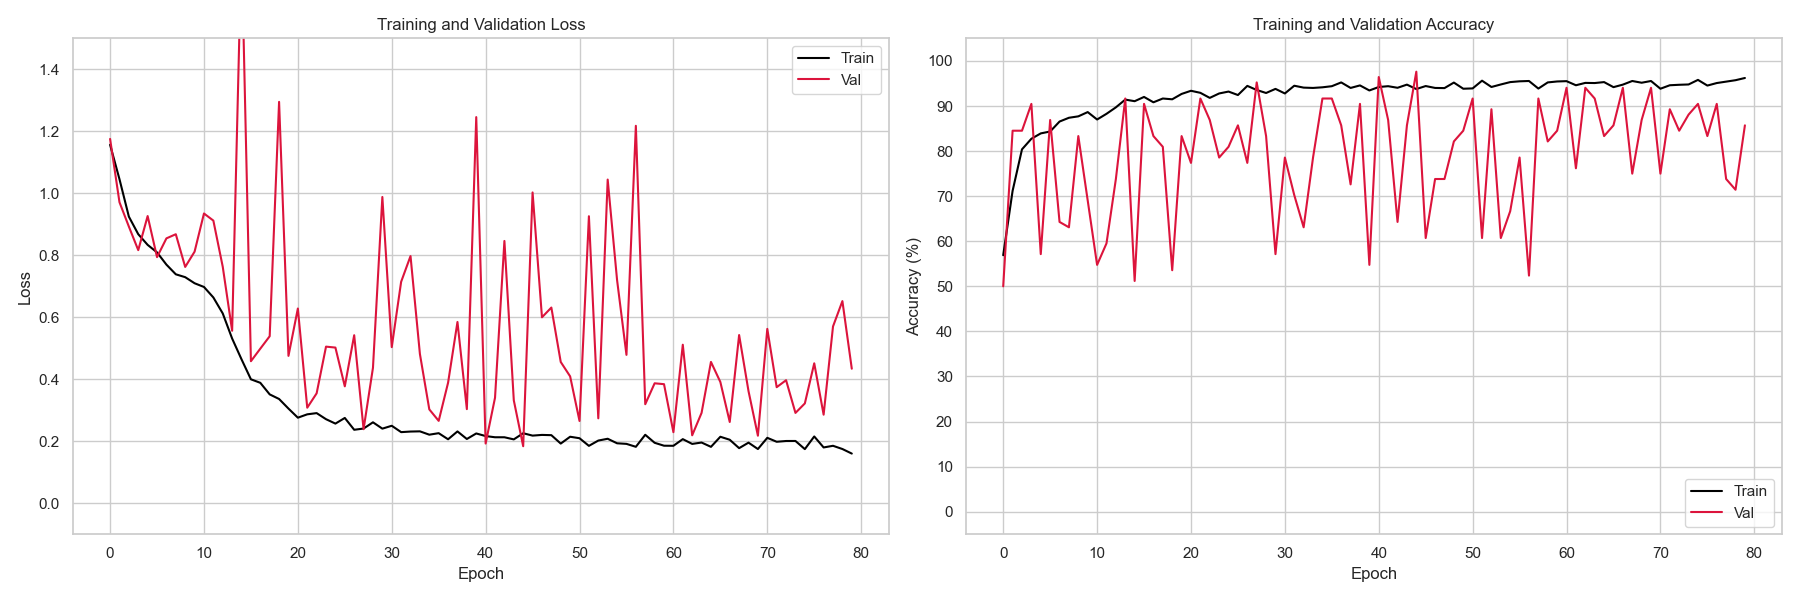

Iteration,Train Acc,Val Acc,Test Acc
32,97.584,97.619,83.333


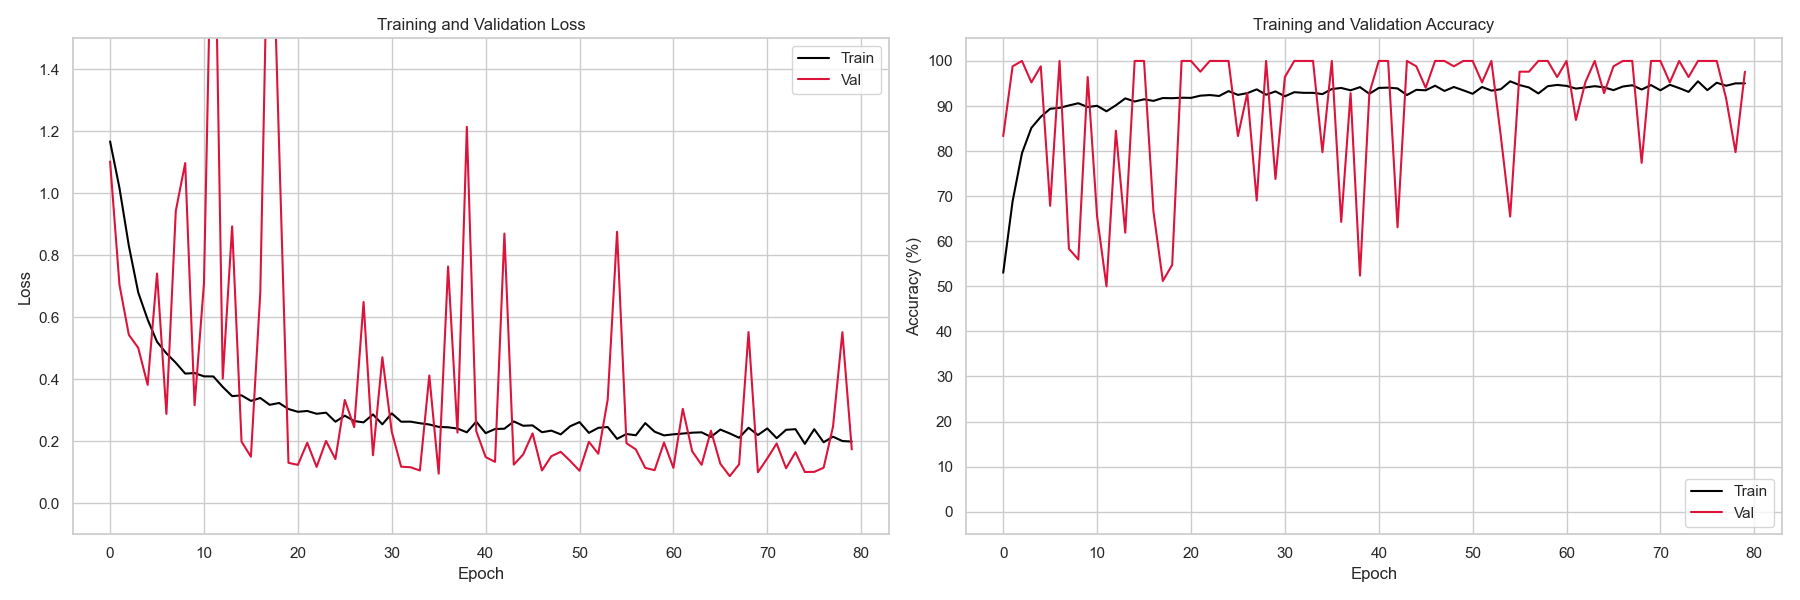

Iteration,Train Acc,Val Acc,Test Acc
33,98.634,100.000,95.000


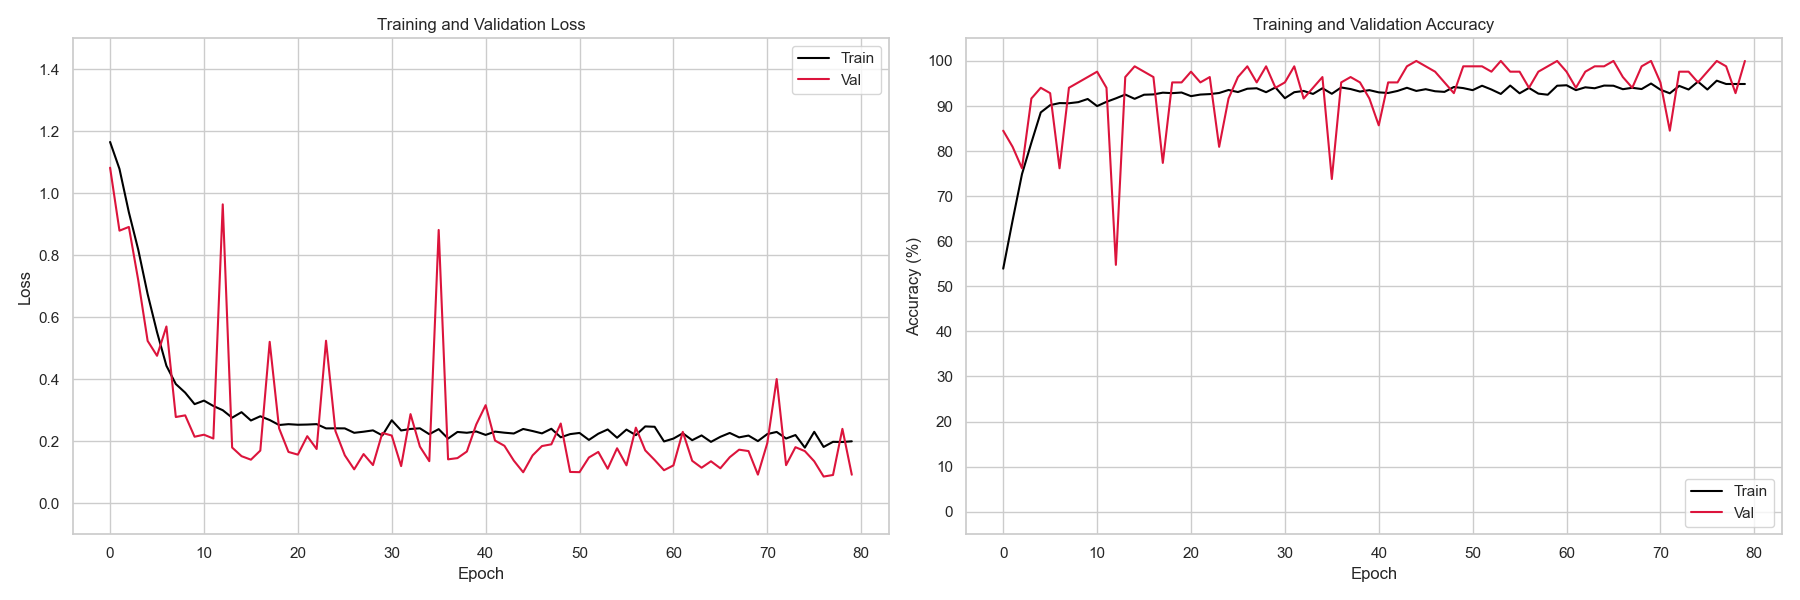

Iteration,Train Acc,Val Acc,Test Acc
34,99.090,100.000,100.000


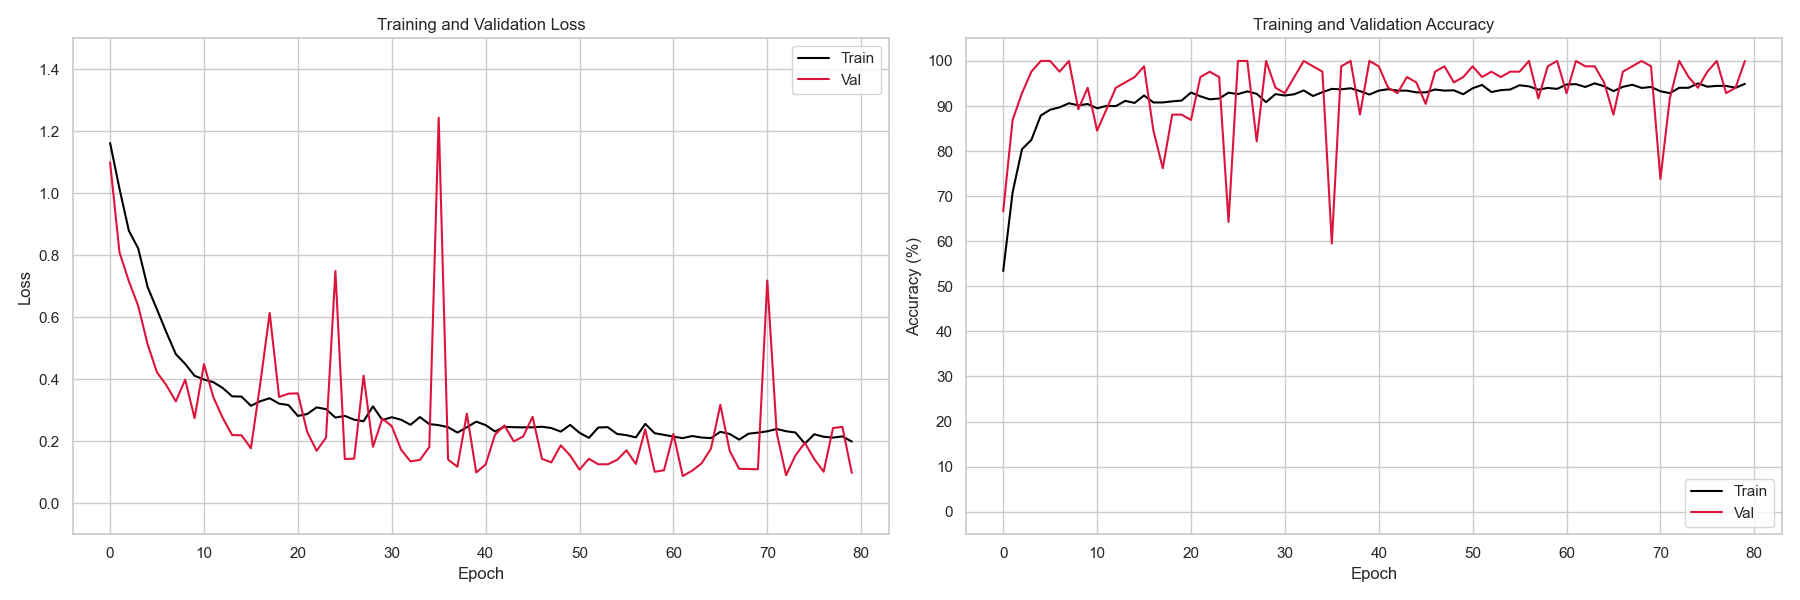

Iteration,Train Acc,Val Acc,Test Acc
35,95.378,98.810,100.000


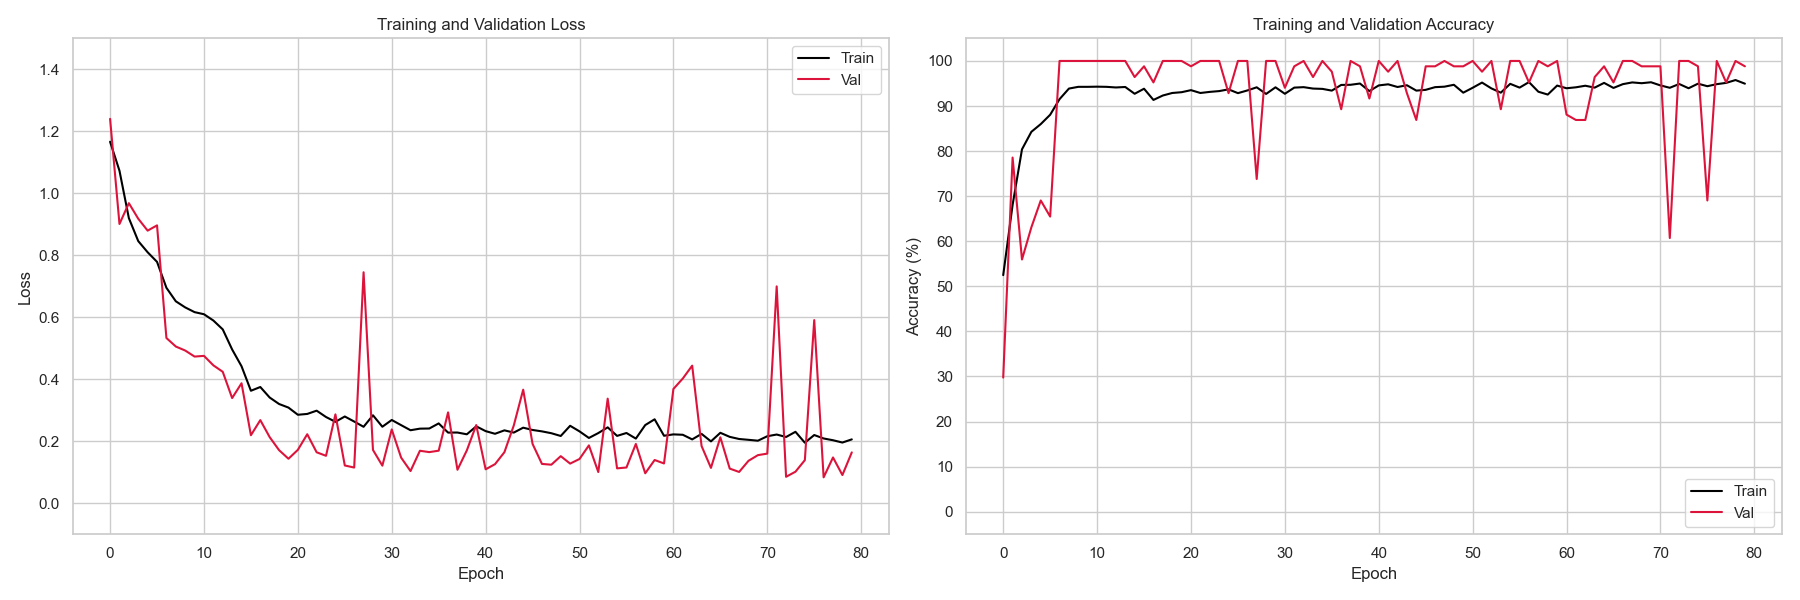

Iteration,Train Acc,Val Acc,Test Acc
36,96.884,98.810,100.000


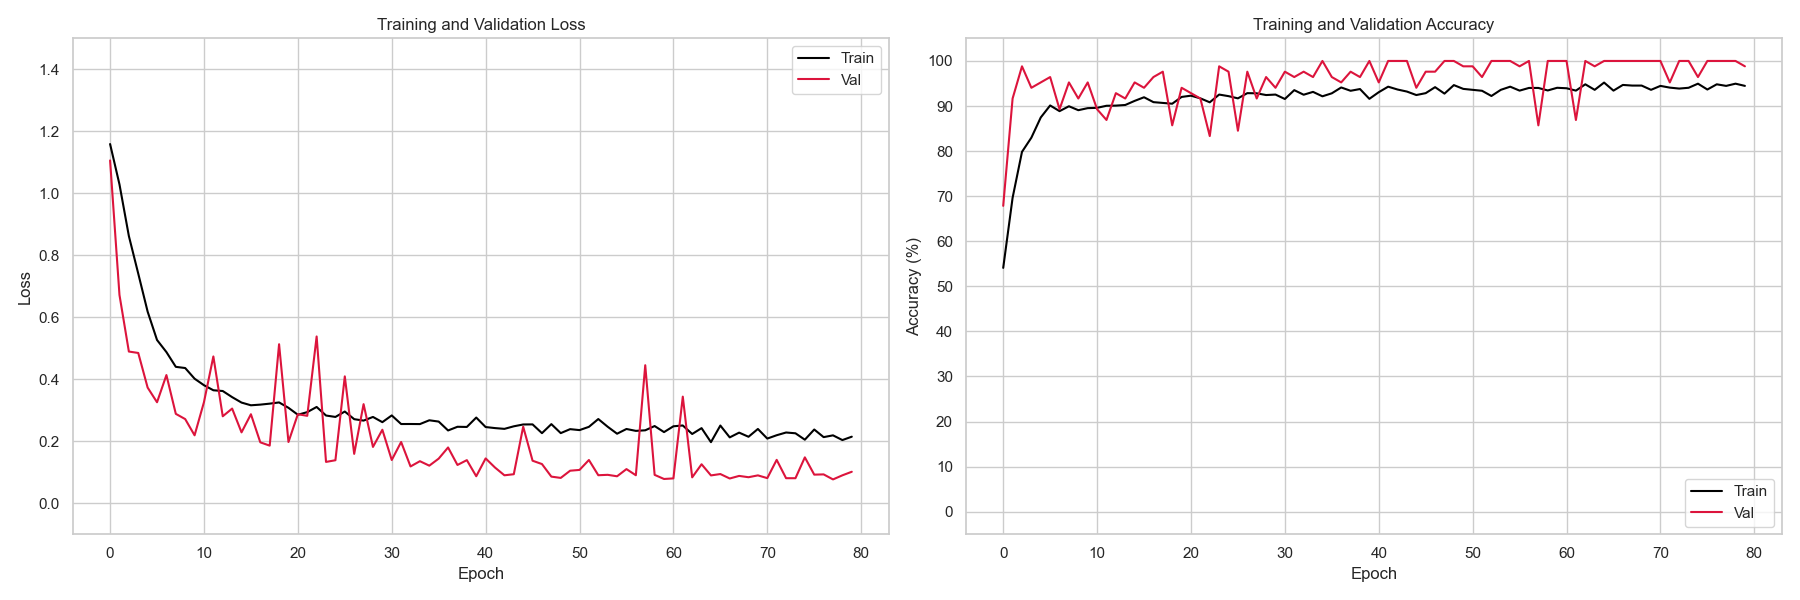

Iteration,Train Acc,Val Acc,Test Acc
37,94.223,100.000,100.000


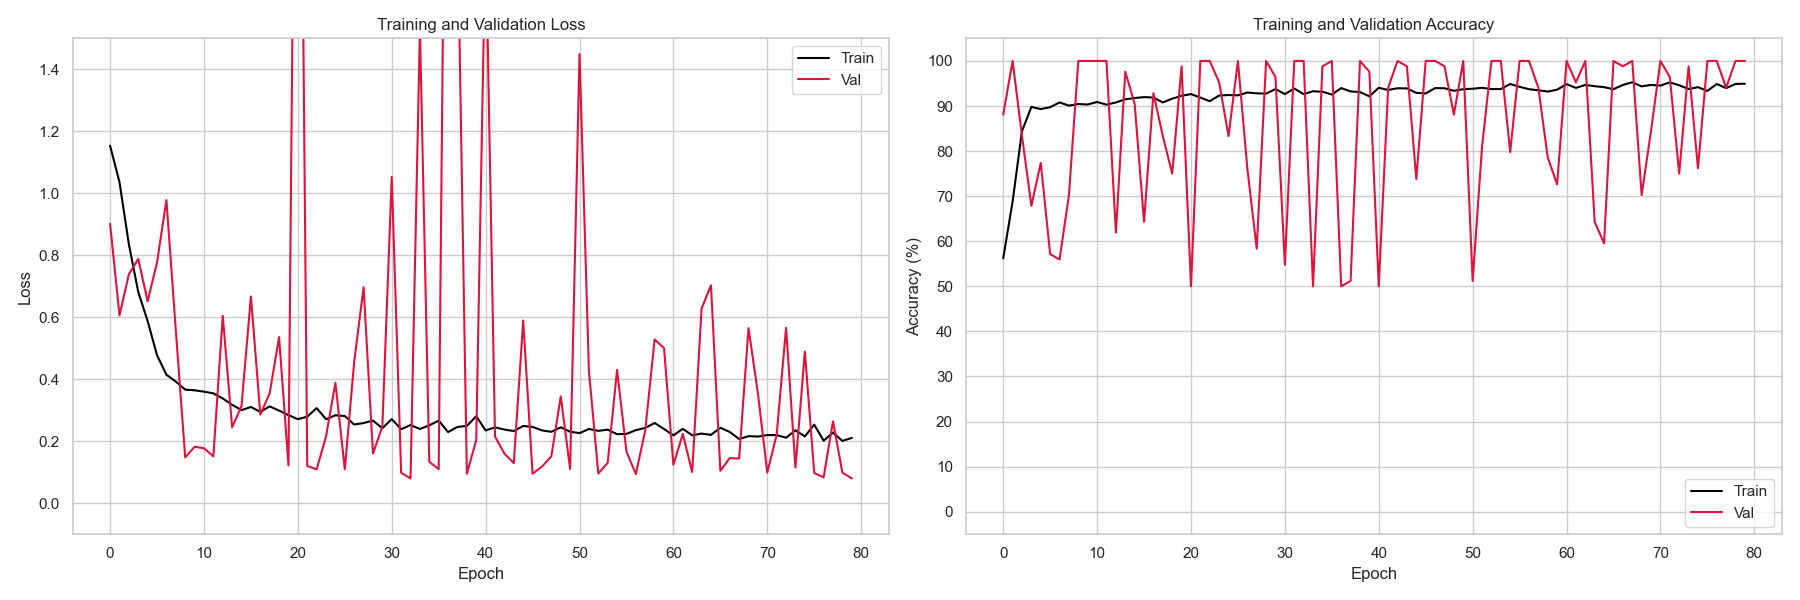

Iteration,Train Acc,Val Acc,Test Acc
38,97.654,75.000,100.000


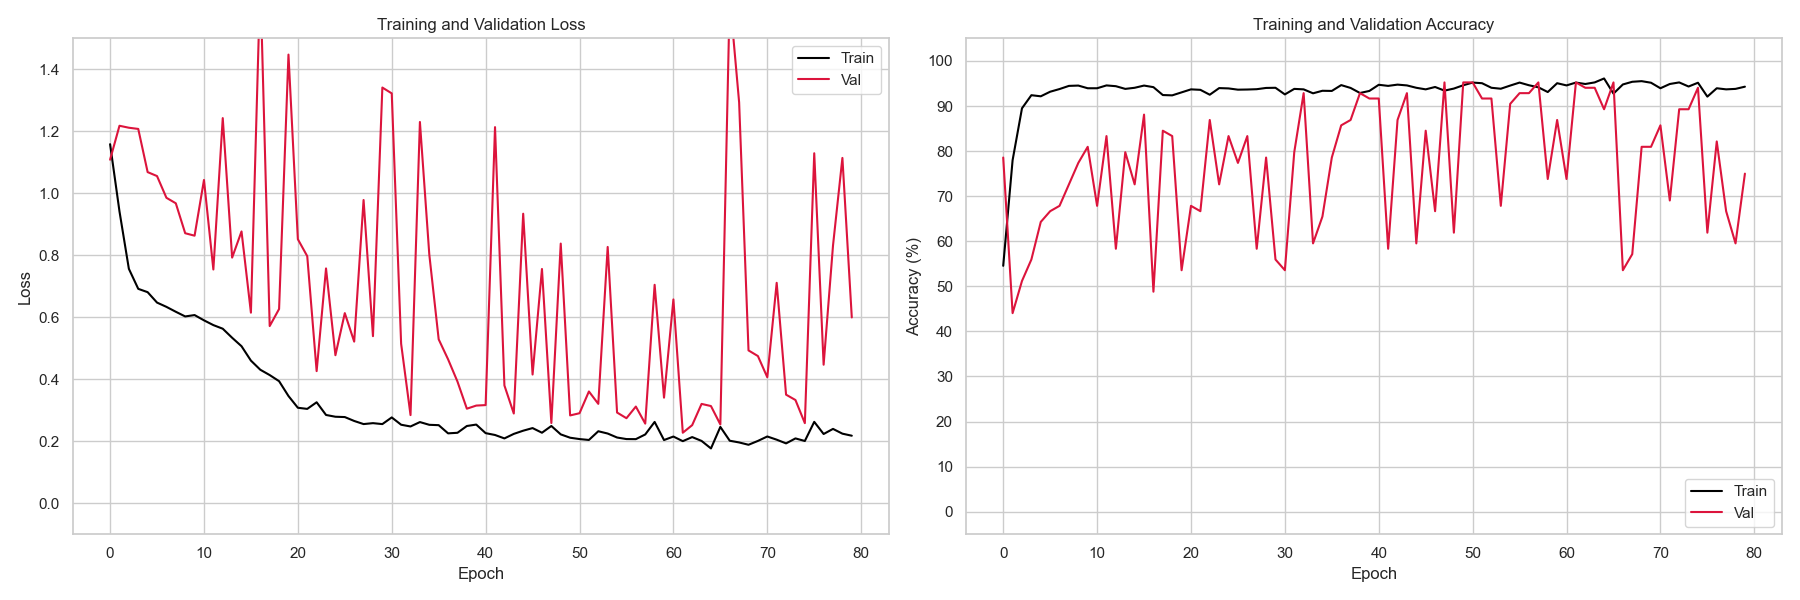

Iteration,Train Acc,Val Acc,Test Acc
39,97.829,100.000,81.667


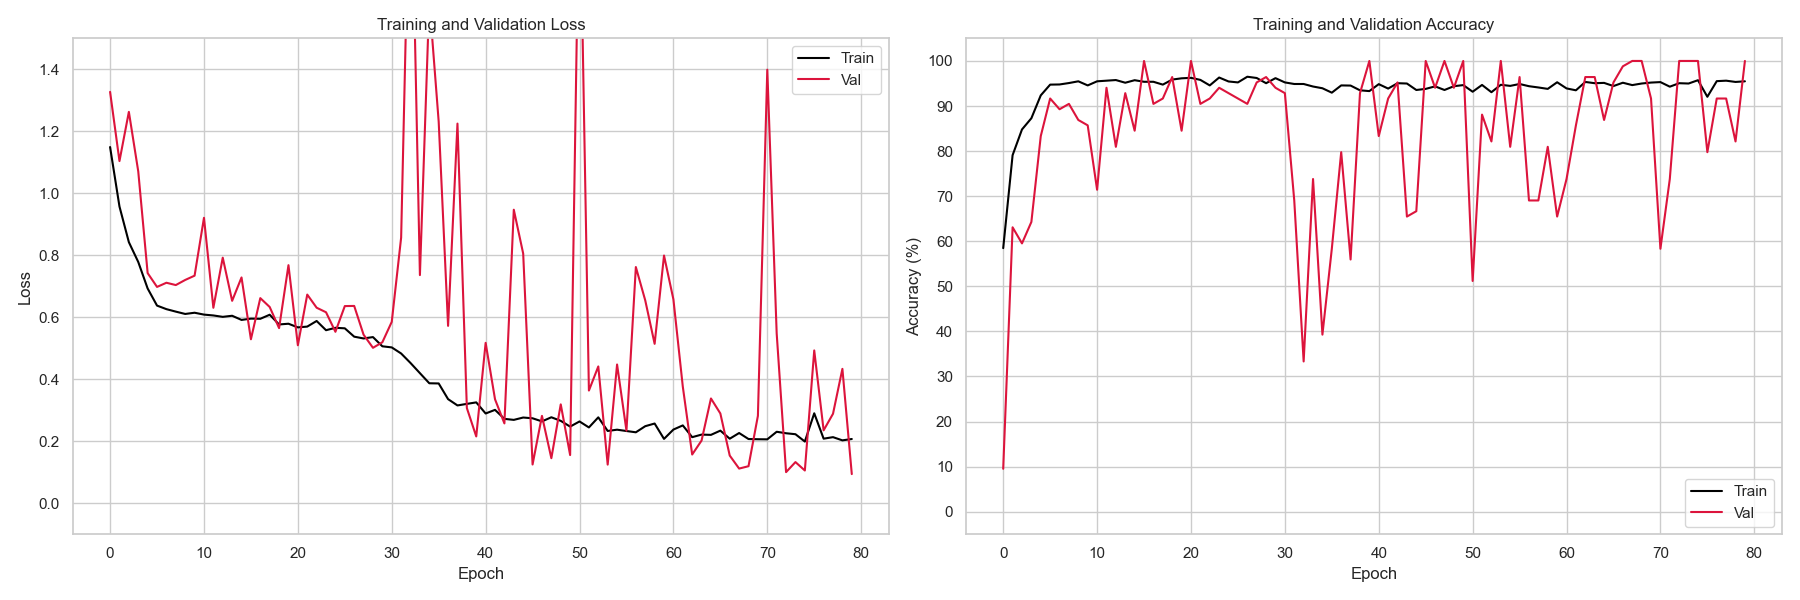

Iteration,Train Acc,Val Acc,Test Acc
40,98.564,100.000,81.667


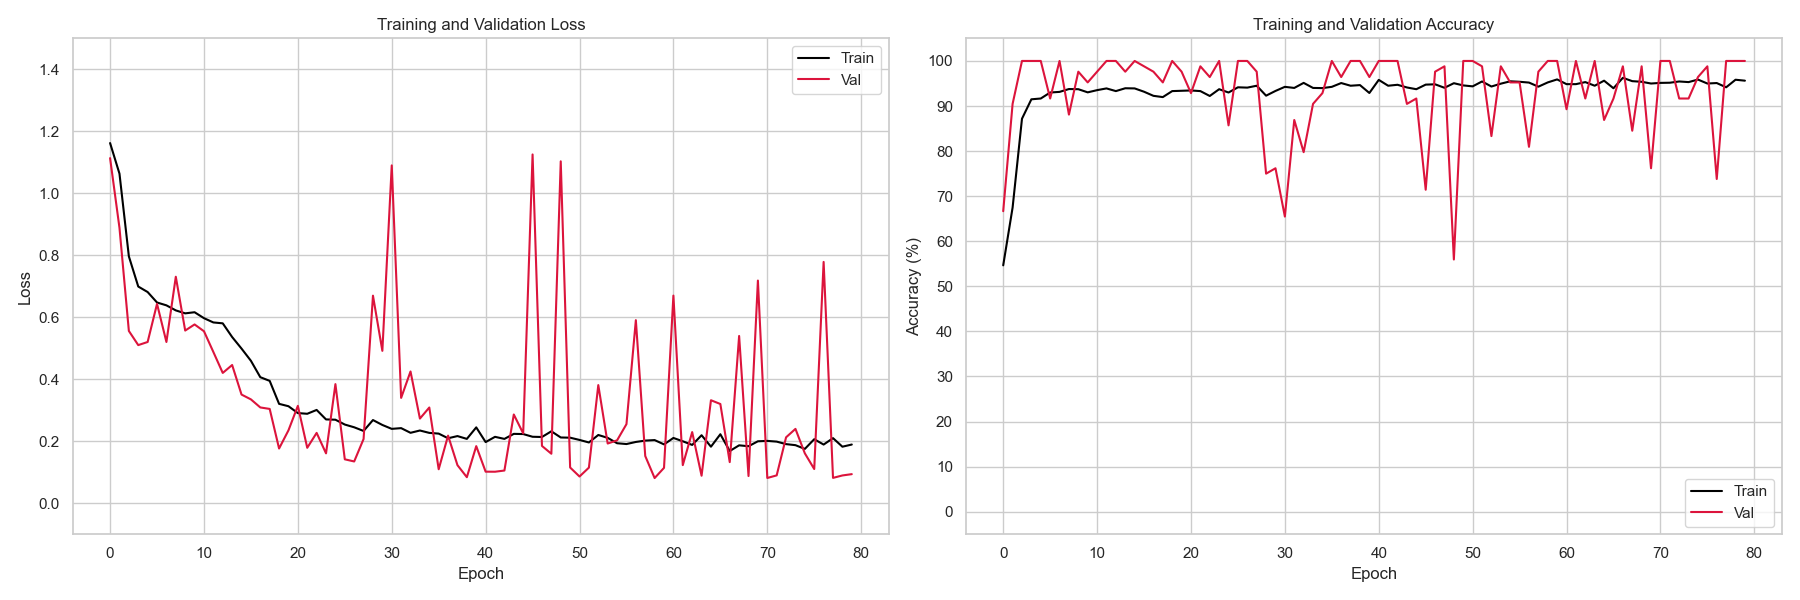

Iteration,Train Acc,Val Acc,Test Acc
41,97.724,95.238,100.000


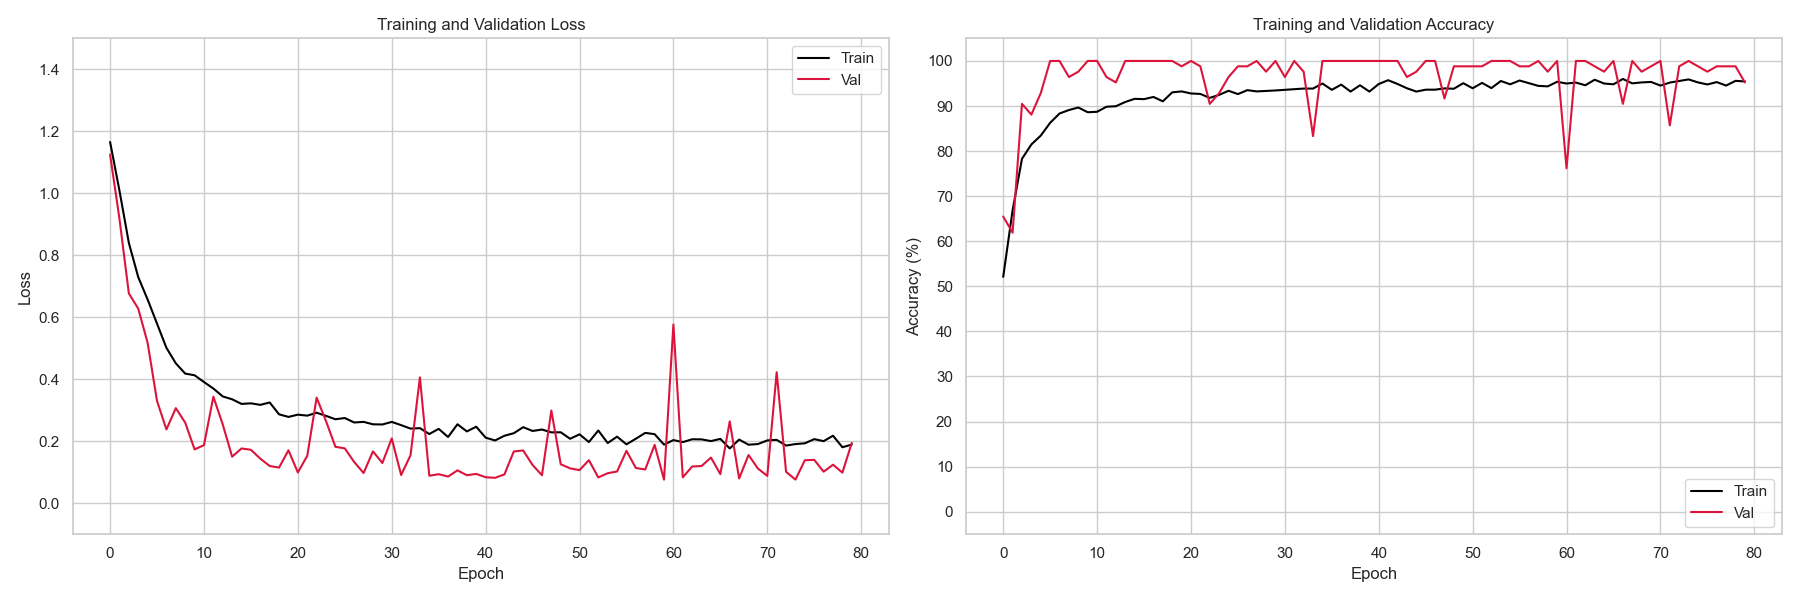

Iteration,Train Acc,Val Acc,Test Acc
42,97.899,100.000,81.667


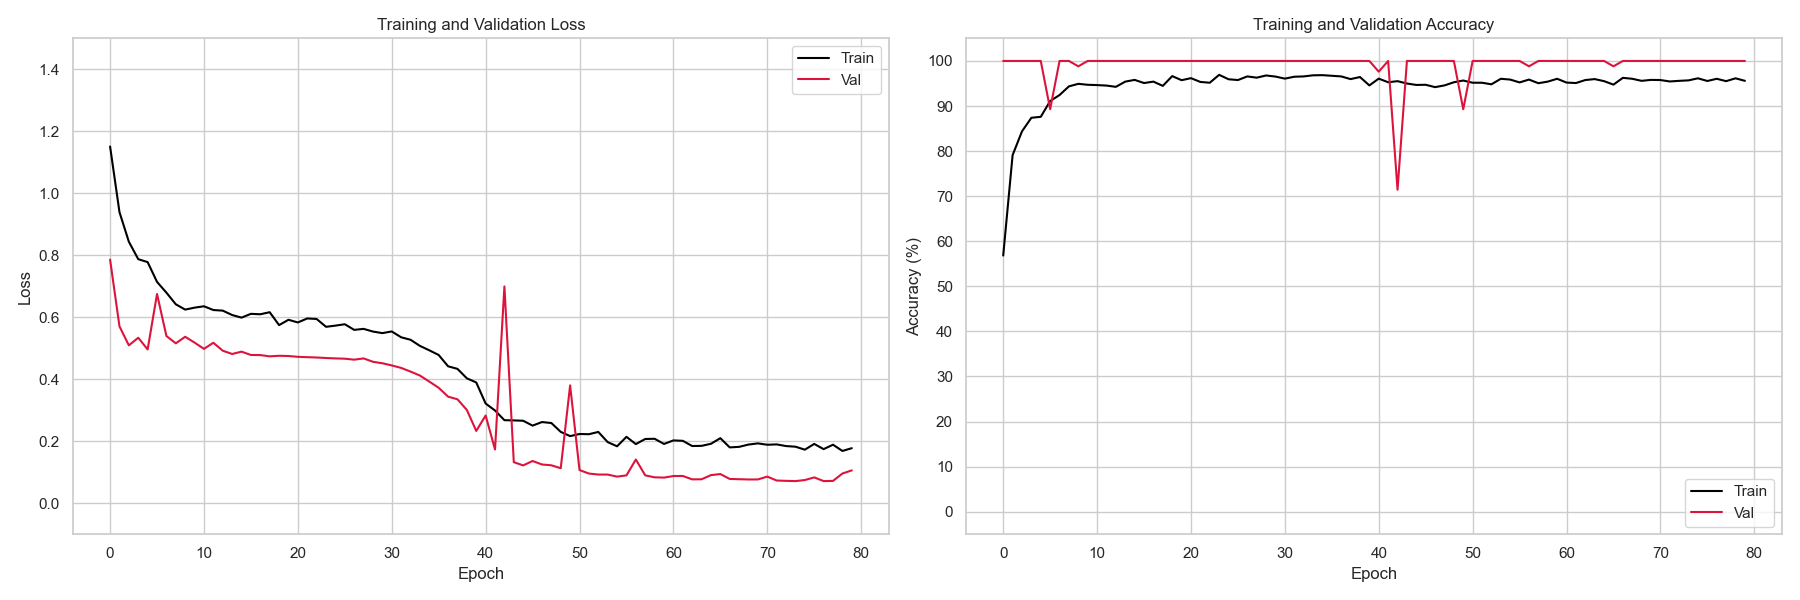

Iteration,Train Acc,Val Acc,Test Acc
43,85.644,70.238,100.000


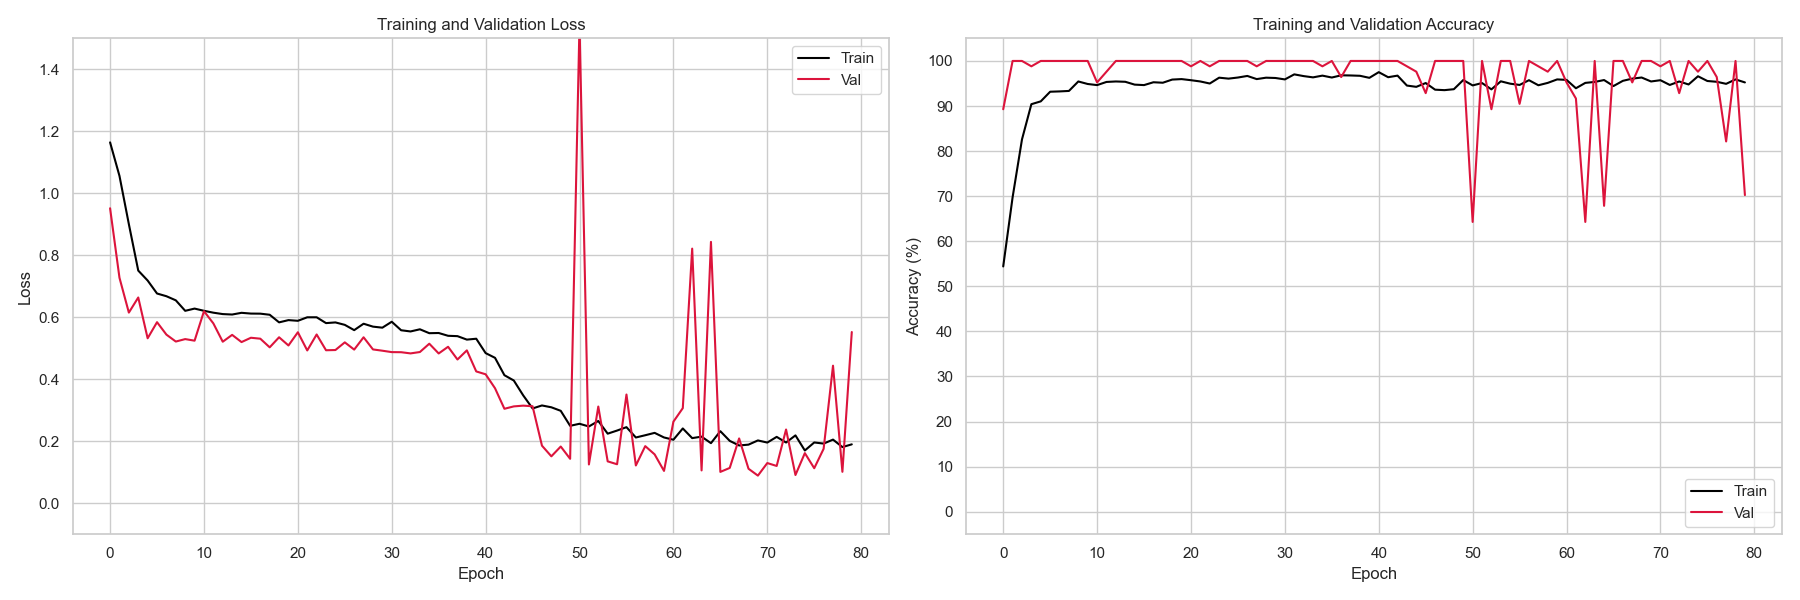

Iteration,Train Acc,Val Acc,Test Acc
44,95.553,100.000,33.333


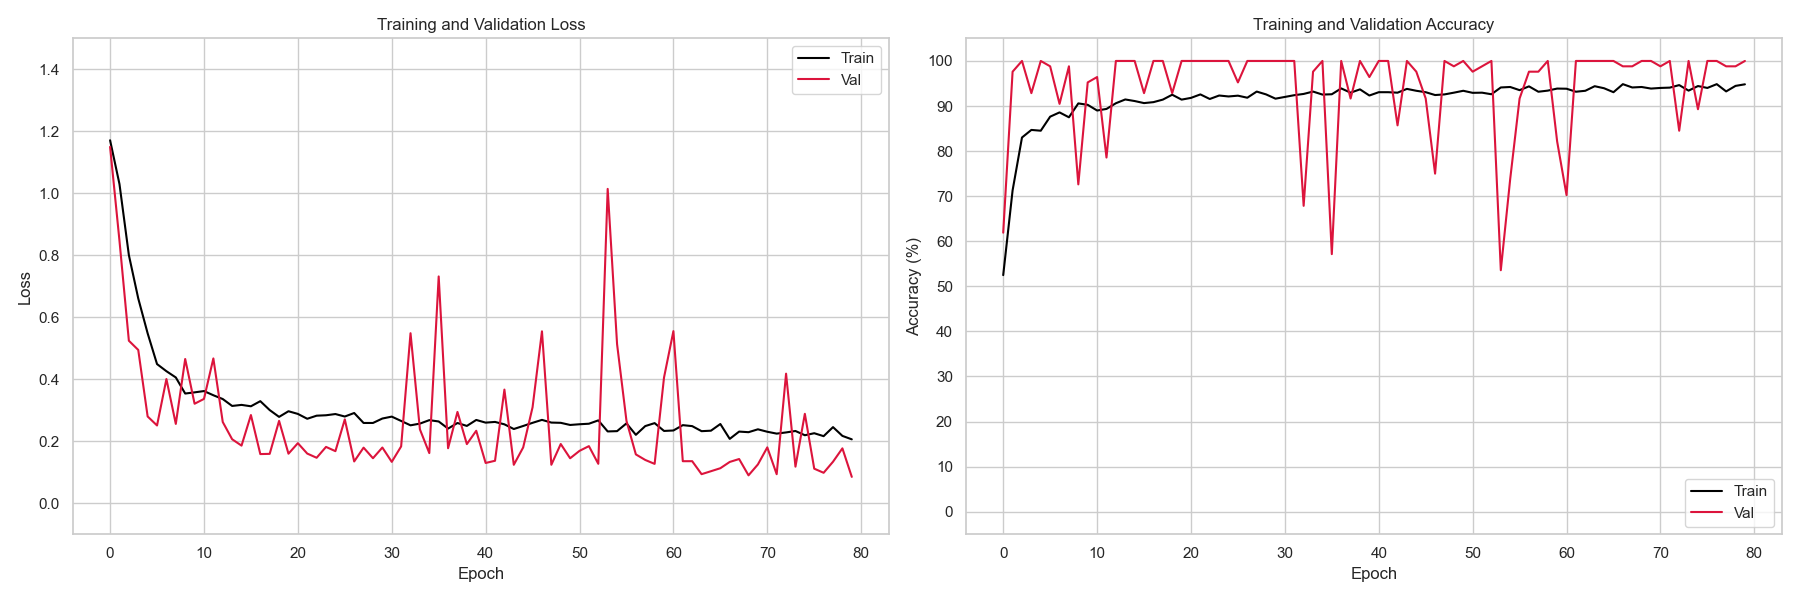

Iteration,Train Acc,Val Acc,Test Acc
45,91.562,98.810,71.667


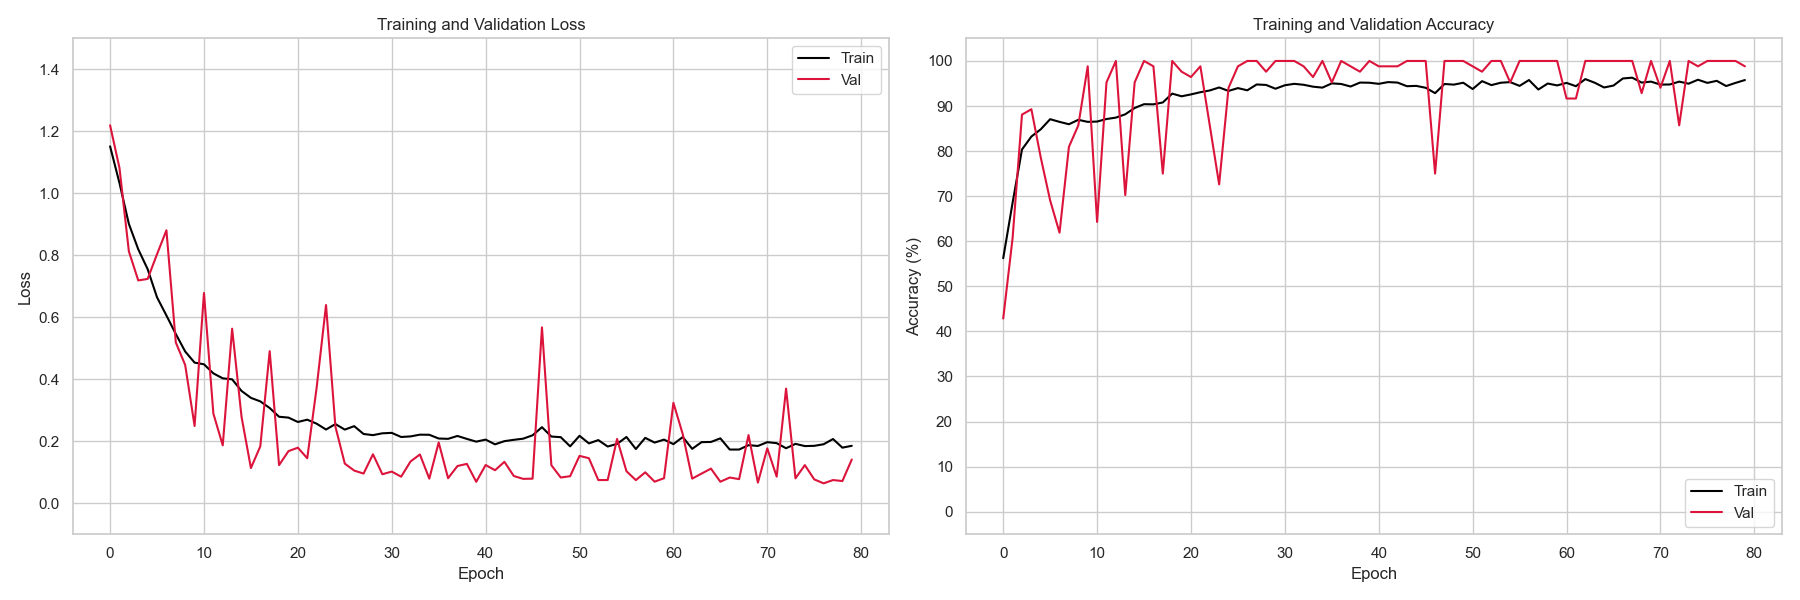

Iteration,Train Acc,Val Acc,Test Acc
46,96.359,96.429,100.000


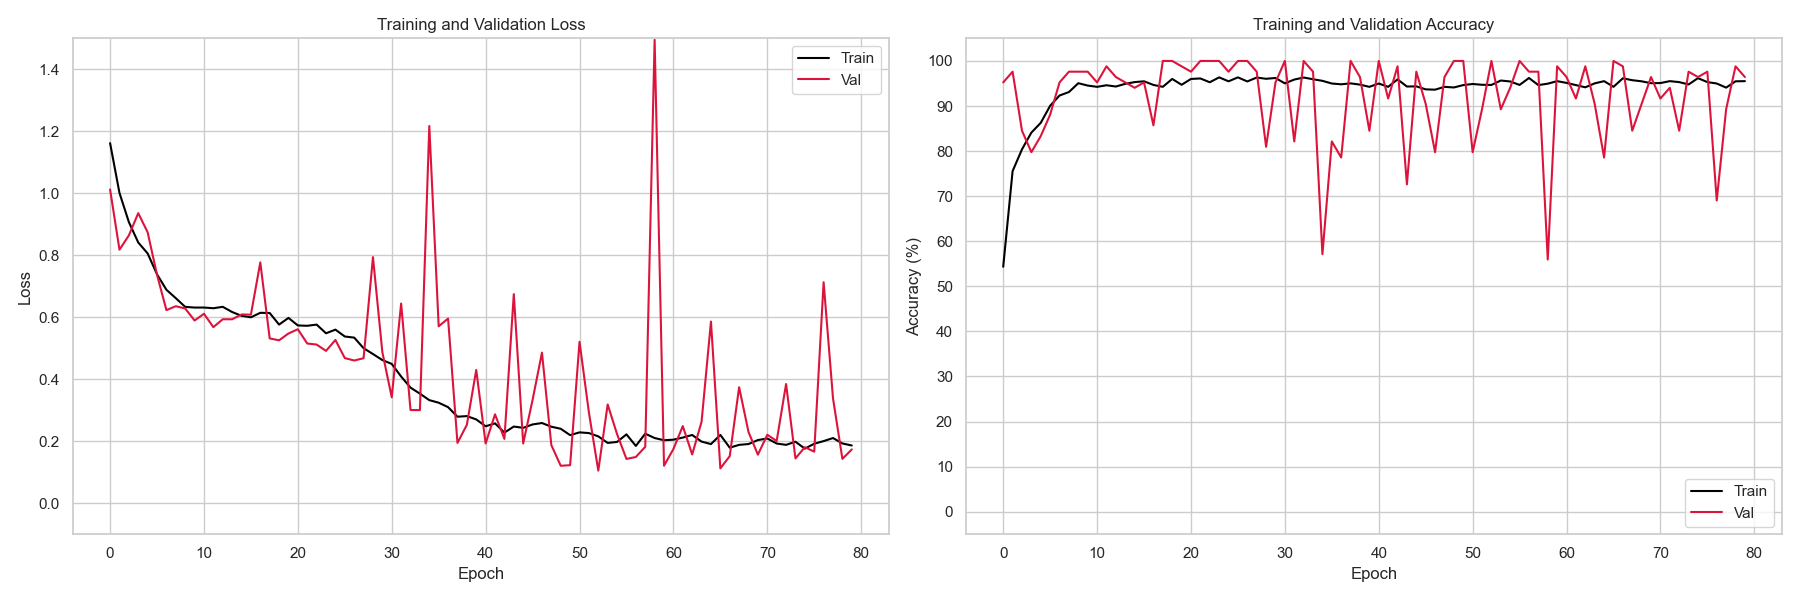

Iteration,Train Acc,Val Acc,Test Acc
47,95.518,80.952,100.000


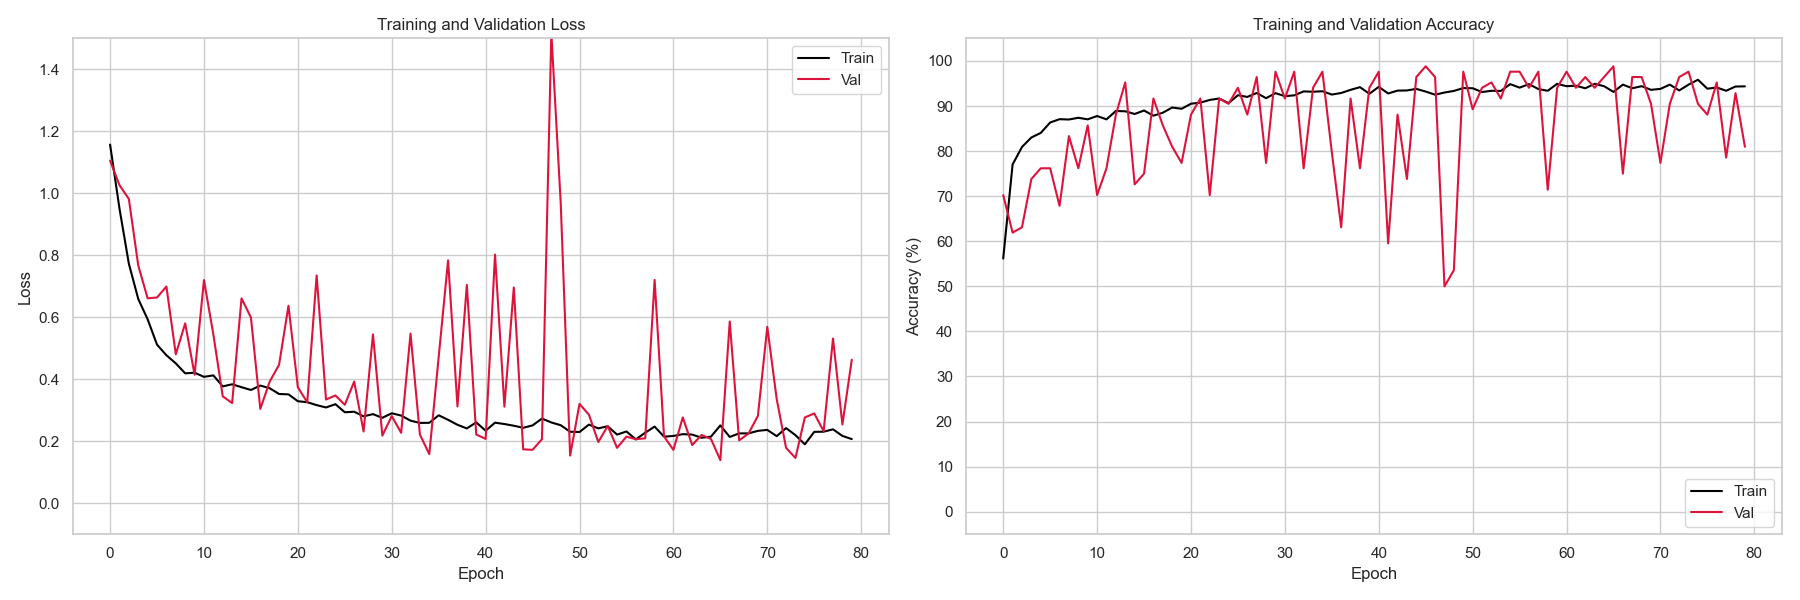

Iteration,Train Acc,Val Acc,Test Acc
48,96.429,98.810,86.667


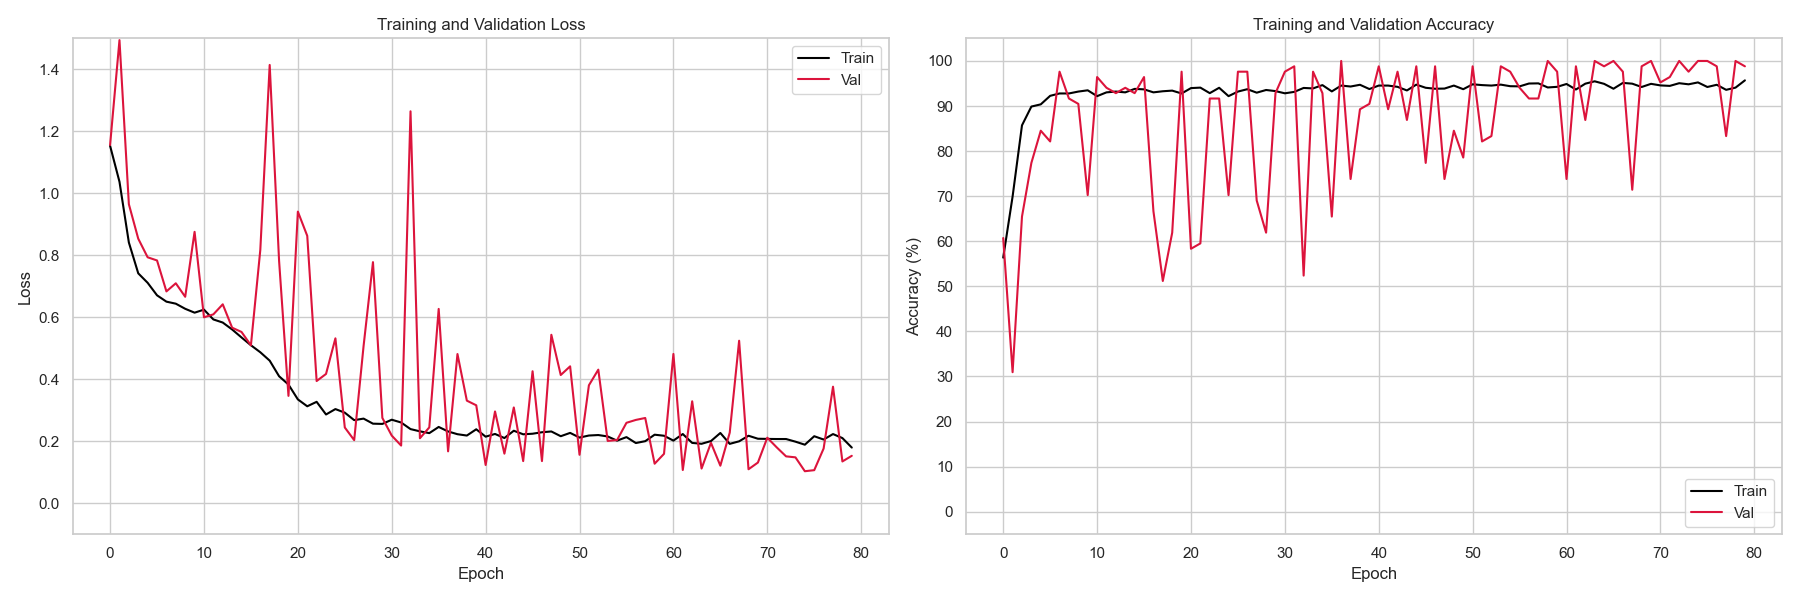

Iteration,Train Acc,Val Acc,Test Acc
49,99.125,98.810,98.333


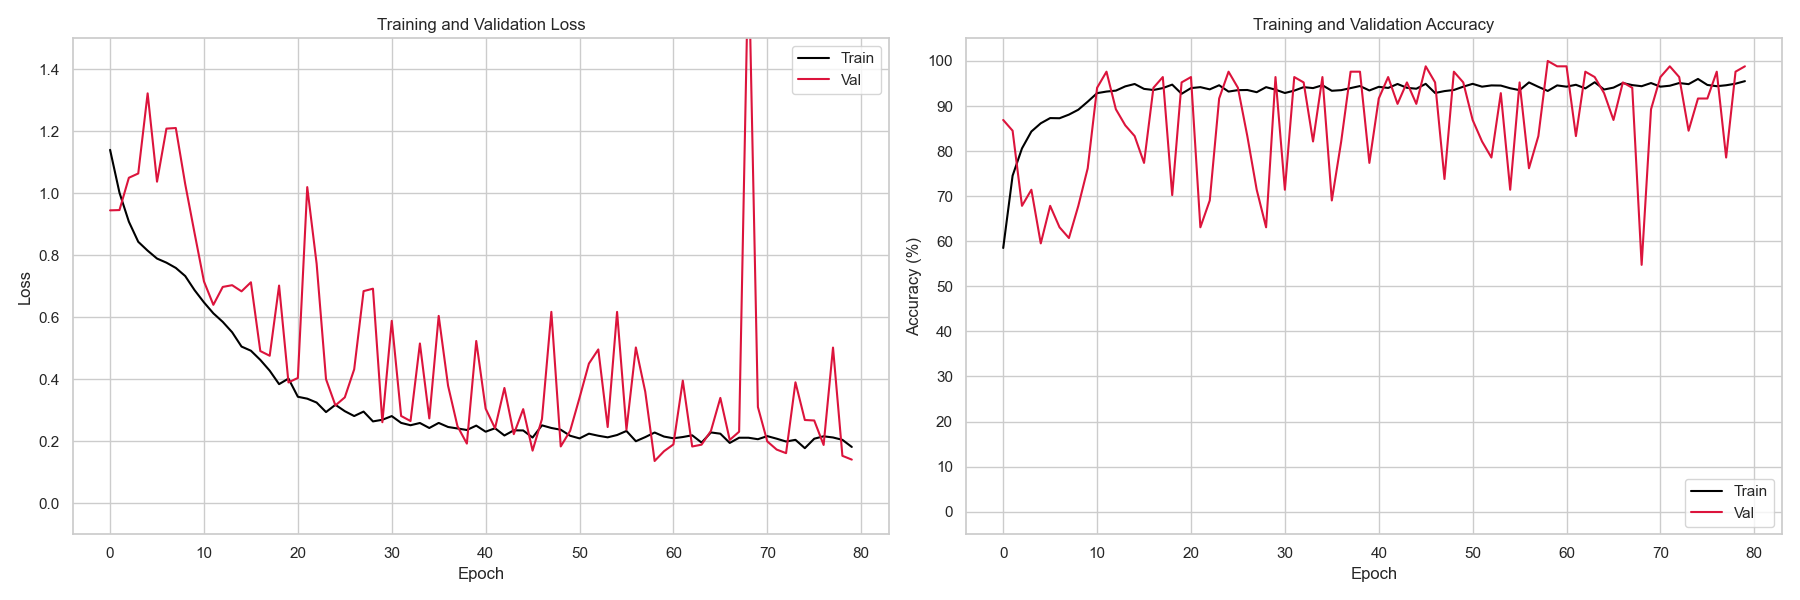

In [6]:
config = {
    "model_name": "MEGNet_CA0R",
    "learning_rate": 1e-3,
    "epochs": 80,
    "batch_size": 16,
    "reg_weight": 0.2,
    "use_channel_attention": True,
    "use_temporal_attention": False,
    "show_summary": True,
    "show_plots": True}

metrics_all, val_accs, test_accs, test_names, intermediate_outputs_pd = kfold_train_multi_val(all_subjects_address, config)

,loss,accuracy,specificity,sensitivity,kappa
train,0.205 ± 0.116,94.826 ± 5.451,93.758 ± 10.104,95.905 ± 7.947,0.897 ± 0.109
validation,0.325 ± 0.394,91.262 ± 11.504,90.143 ± 18.748,92.381 ± 17.143,0.825 ± 0.230
test,0.369 ± 0.396,87.300 ± 17.591,84.733 ± 21.248,89.867 ± 12.418,nan ± nan


,MLT,MLF,MLC,MLP,MLO,MZ,MRT,MRF,MRC,MRP,MRO
mean,0.061,0.118,0.080,0.064,0.081,0.078,0.087,0.117,0.120,0.057,0.137
std,0.224,0.306,0.254,0.223,0.252,0.252,0.255,0.305,0.297,0.199,0.324


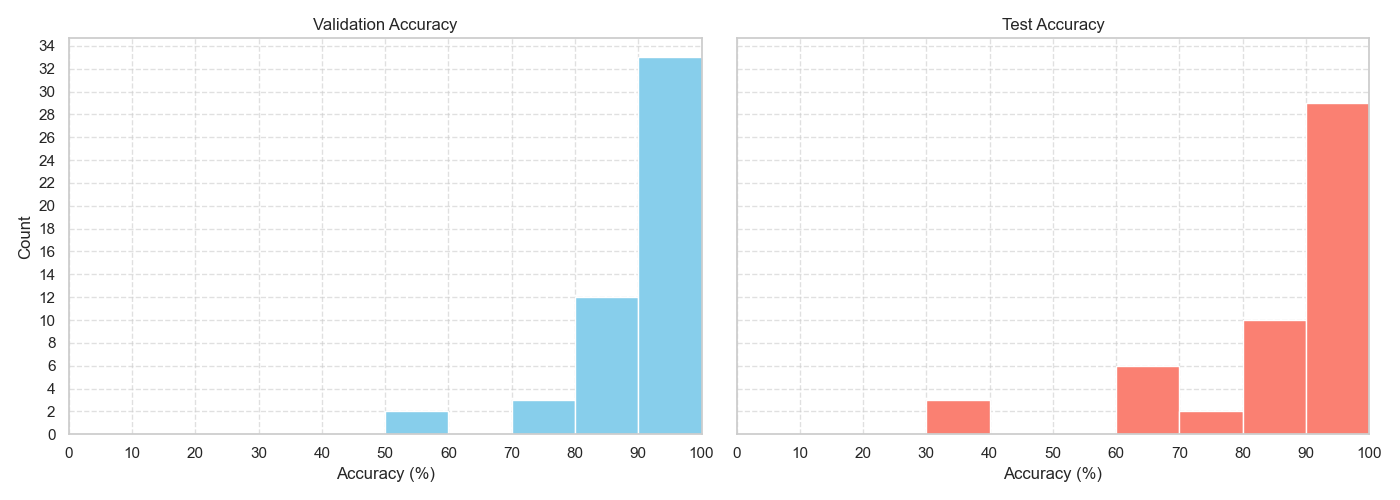

In [7]:
summary.summarize_all(metrics_all, intermediate_outputs_pd, test_names, test_accs, val_accs, 
                      model_name=config["model_name"], show_test_acc=False, show_histogram=False)

plots.plot_accuracy_histograms(val_accs, test_accs)

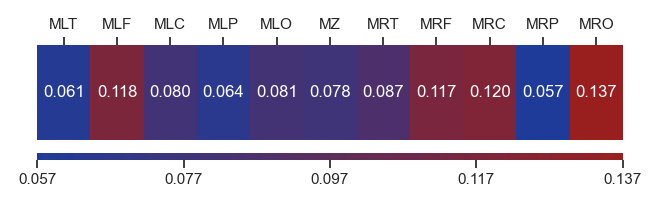

In [8]:
vis_attention.plot_attention_heatmap(summary.summarize_attention(intermediate_outputs_pd).iloc[0],
    use_channel_attention=config['use_channel_attention'], show_hex=False)